In [1]:
# ============================================================
# Part 0 — Global configuration (single source of truth)
# ============================================================
# Dataset loaded directly from the Neuroblastoma EHRs Open Data Repository
# (Chicco et al., 2022) — no Google Drive or manual download needed.

DATA_PATH = 'https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/GSE3960_cleaned_data.csv'

# ------------------------------------------------------------
# Runtime
# ------------------------------------------------------------
FORCE_CPU = True          # revised pipeline runs on CPU (see notes)
USE_GPU   = False
RANDOM_SEED = 42
ENABLE_DIFFERENTIAL_PRIVACY = False   # DP sweep is a separate, self-contained part

# ------------------------------------------------------------
# Conditional generator (CTGAN) — replaces the previous FAST_ML preset
# ------------------------------------------------------------
GEN_CONFIG = {
    "name":              "CTGAN",
    "epochs":            6000,       # fixed by the convergence check, not a default
    "batch_size":        50,       # must be a multiple of `pac`
    "pac":               10,
    "generator_dim":     (128, 128),
    "discriminator_dim": (128, 128),
    "embedding_dim":     128,
    "discriminator_steps": 1,
    "cuda":              False,    # explicit: prevents silent CPU/GPU switching
    "verbose":           False,
}

# Conditional sampling: synthetic rows are generated for the minority class only,
# conditioned on the target column via CTGAN's conditional vector.
SYNTH_RATIO      = 0.5              # n_syn = round(SYNTH_RATIO * n_minority_train)
SYNTH_RATIO_GRID = [0.25, 0.5, 1.0, 2.0, "parity"] # sensitivity analysis (primary cohort only)
MIN_MINORITY_FOR_SYNTHESIS = 5      # below this, augmentation is skipped and logged
AUDIT_N_SAMPLES = 100
# ------------------------------------------------------------
# Synthetic-data quality and privacy audit
# ------------------------------------------------------------
AUDIT_CONFIG = {
    "mmd_kernel":        "rbf",
    "mmd_bandwidth":     "median",  # median heuristic, computed on real data only
    "mmd_permutations":  199,
    "jsd_bins":          10,        # quantile bins, edges from real data only
    "jsd_base":          2,         # JSD in [0, 1]
    "dcr_percentile":    5,         # reference percentile of the real-real distribution
    "audit_every_n_folds": 1,       # set >1 if the audit becomes a bottleneck
}

# ------------------------------------------------------------
# Reproducibility manifest (populated as the pipeline runs)
# ------------------------------------------------------------
MANIFEST = {
    "seed": RANDOM_SEED,
    "data_path": DATA_PATH,
    "data_sha256": None,      # filled at load time
    "library_versions": {},   # filled after installs
    "generator": GEN_CONFIG,
    "synth_ratio": SYNTH_RATIO,
    "audit": AUDIT_CONFIG,
    "runtime": {"force_cpu": FORCE_CPU},
}

# ------------------------------------------------------------
# Determinism
# ------------------------------------------------------------
def set_all_seeds(seed: int = RANDOM_SEED) -> None:
    """Seed every RNG used downstream. Safe to call before torch is installed."""
    import os, random
    import numpy as np
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True, warn_only=True)
    except ImportError:
        pass  # torch not yet installed; re-invoke after Part 1b

set_all_seeds(RANDOM_SEED)

print(f"[Config] DATA_PATH      : {DATA_PATH}")
print(f"[Config] Runtime        : CPU (FORCE_CPU={FORCE_CPU})")
print(f"[Config] Generator      : {GEN_CONFIG['name']} "
      f"({GEN_CONFIG['epochs']} epochs, batch={GEN_CONFIG['batch_size']}, pac={GEN_CONFIG['pac']})")
print(f"[Config] Synthetic ratio: {SYNTH_RATIO} (grid: {SYNTH_RATIO_GRID})")
print(f"[Config] Seed           : {RANDOM_SEED}")

[Config] DATA_PATH      : https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/GSE3960_cleaned_data.csv
[Config] Runtime        : CPU (FORCE_CPU=True)
[Config] Generator      : CTGAN (6000 epochs, batch=50, pac=10)
[Config] Synthetic ratio: 0.5 (grid: [0.25, 0.5, 1.0, 2.0, 'parity'])
[Config] Seed           : 42


In [2]:
# ============================================================
# Part 1 — Environment setup, runtime diagnostics, validation strategy
# ============================================================
# Reports and installs the environment, records it in MANIFEST, and defines
# the validation protocol. It must not modify any value set in Part 0.

# --- Guard: Part 0 must have been executed ---
for _v in ["DATA_PATH", "RANDOM_SEED", "FORCE_CPU", "GEN_CONFIG", "MANIFEST"]:
    if _v not in globals():
        raise NameError(f"'{_v}' not found — run Part 0 (global configuration) first.")

# ------------------------------------------------------------
# Installs
# ------------------------------------------------------------
# Core scientific stack
!pip -q install pandas numpy scikit-learn matplotlib requests

# Remove any conflicting pre-existing installs
!pip -q uninstall -y sdv sdmetrics ctgan || true

# SDV 1.27.x — pulls ctgan>=0.11 (and torch) plus a compatible sdmetrics
!pip -q install "sdv>=1.27,<1.28"

# Differential privacy (objective perturbation, Chaudhuri et al. 2011)
!pip -q install diffprivlib

# Post-hoc explainability
!pip -q install shap

# ------------------------------------------------------------
# Library versions
# ------------------------------------------------------------
import os, sys, platform, subprocess, importlib, inspect

_PACKAGES = ["numpy", "pandas", "sklearn", "scipy", "matplotlib",
             "torch", "sdv", "ctgan", "sdmetrics", "diffprivlib", "shap"]

print("[Libraries]")
for _name in _PACKAGES:
    try:
        _mod = importlib.import_module(_name)
        _ver = getattr(_mod, "__version__", "unknown")
        MANIFEST["library_versions"][_name] = _ver
        print(f"  {_name:<12}: {_ver}")
    except ImportError as _e:
        MANIFEST["library_versions"][_name] = None
        print(f"  {_name:<12}: NOT AVAILABLE ({_e})")

# ------------------------------------------------------------
# Runtime diagnostics (read-only)
# ------------------------------------------------------------
def _probe_nvidia_smi():
    """Detect a GPU for reporting purposes only; does not affect configuration."""
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name,memory.total',
             '--format=csv,noheader,nounits'],
            stderr=subprocess.STDOUT
        )
        name, mem = [x.strip() for x in out.decode('utf-8').strip().splitlines()[0].split(',')]
        return name, int(mem)
    except Exception:
        return None, None


def _probe_ram_gb():
    try:
        return round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 1024**3, 1)
    except Exception:
        return None


GPU_NAME, GPU_MEM_MB = _probe_nvidia_smi()

try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
except ImportError:
    CUDA_AVAILABLE = False

DEVICE = 'cpu' if FORCE_CPU else ('cuda' if CUDA_AVAILABLE else 'cpu')

# The generator must agree with the runtime policy declared in Part 0
if GEN_CONFIG["cuda"] and DEVICE == 'cpu':
    raise RuntimeError(
        "GEN_CONFIG['cuda'] is True but the runtime policy resolves to CPU. "
        "Reconcile Part 0 before proceeding."
    )

MANIFEST["runtime"].update({
    "device": DEVICE,
    "force_cpu": FORCE_CPU,
    "gpu_present": GPU_NAME is not None,
    "gpu_name": GPU_NAME,
    "gpu_mem_mb": GPU_MEM_MB,
    "cuda_available": CUDA_AVAILABLE,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "cpu_count": os.cpu_count(),
    "ram_gb": _probe_ram_gb(),
})

# ------------------------------------------------------------
# Validation strategy
# ------------------------------------------------------------
# Repeated hold-out (Monte Carlo CV): each iteration is an independent
# stratified random split. Use N_REPEATS = 100 for final results.
N_REPEATS         = 100    # set to N_REPEATS_QUICK for smoke tests
N_REPEATS_QUICK   = 10
HOLDOUT_TEST_SIZE = 0.20   # 80/20 train/test per iteration

MANIFEST["validation"] = {
    "scheme": "repeated stratified hold-out",
    "n_repeats": N_REPEATS,
    "test_size": HOLDOUT_TEST_SIZE,
}

# ------------------------------------------------------------
# Pre-flight checks on the generator configuration
# ------------------------------------------------------------
from sdv.single_table import CTGANSynthesizer

_valid   = set(inspect.signature(CTGANSynthesizer.__init__).parameters) - {"self", "metadata"}
_passed  = set(GEN_CONFIG) - {"name"}          # 'name' is bookkeeping, not a constructor arg
_unknown = _passed - _valid
if _unknown:
    raise ValueError(
        f"GEN_CONFIG contains keys CTGANSynthesizer does not accept: {sorted(_unknown)}"
    )

if GEN_CONFIG["batch_size"] % GEN_CONFIG["pac"] != 0:
    raise ValueError(
        f"batch_size ({GEN_CONFIG['batch_size']}) must be a multiple of pac ({GEN_CONFIG['pac']})."
    )

# ------------------------------------------------------------
# Re-seed now that torch is installed
# ------------------------------------------------------------
set_all_seeds(RANDOM_SEED)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\n[Runtime]")
print(f"  DEVICE (in use)   : {DEVICE}")
print(f"  Python / platform : {platform.python_version()} on {platform.system()}")
print(f"  CPU cores / RAM   : {os.cpu_count()} / {_probe_ram_gb()} GB")
print(f"  GPU present       : {GPU_NAME or 'none'}"
      + (" (detected but unused — CPU run by design)" if GPU_NAME else ""))
print(f"\n[Validation] Repeated hold-out: {N_REPEATS} iterations, test_size={HOLDOUT_TEST_SIZE}")
print(f"[Generator ] {GEN_CONFIG['name']}: {GEN_CONFIG['epochs']} epochs, "
      f"batch={GEN_CONFIG['batch_size']}, pac={GEN_CONFIG['pac']}, "
      f"dims={GEN_CONFIG['generator_dim']}")
print(f"[Seed      ] {RANDOM_SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.8/186.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.0/207.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 4.2 MB/s eta 0:00:00
[Libraries]
  numpy       : 2.0.2
  pandas      : 2.2.2
  sklearn     : 1.6.1
  scipy       : 1.16.3
  matplotlib  : 3.10.0
  torch       : 2.11.0+cpu
  sdv         : 1.27.0
  ctgan       : 0.12.1
  sdmetrics   : 0.28.2
  diffprivlib : 0.6.6
  shap        : 0.52.0

[Runtime]
  DEVICE (in

In [3]:
# ============================================================
# Part 2 — Data ingestion, profiling, and evaluation metrics
# ============================================================

import io, json, hashlib, warnings
import numpy as np
import pandas as pd
import requests
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    brier_score_loss,
)

# Silence only the known, expected noise; keep everything else visible.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*n_quantiles.*")

# ------------------------------------------------------------
# Loading with content hashing (for the reproducibility manifest)
# ------------------------------------------------------------
def load_table(path_or_url: str) -> tuple[pd.DataFrame, str]:
    """Load a tabular file and return (dataframe, sha256 of the raw bytes).

    Hashing the exact bytes that are parsed — rather than the parsed frame —
    makes the manifest verifiable against the published source file.
    """
    lower = path_or_url.lower()

    if path_or_url.startswith(("http://", "https://")):
        response = requests.get(path_or_url, timeout=60)
        response.raise_for_status()
        raw = response.content
    else:
        with open(path_or_url, "rb") as fh:
            raw = fh.read()

    digest = hashlib.sha256(raw).hexdigest()
    buffer = io.BytesIO(raw)

    if lower.endswith(".csv"):
        frame = pd.read_csv(buffer)
    elif lower.endswith((".tsv", ".txt")):
        frame = pd.read_csv(buffer, sep="\t")
    elif lower.endswith((".xlsx", ".xls")):
        frame = pd.read_excel(buffer)
    elif lower.endswith(".json"):
        frame = pd.read_json(buffer)
    else:
        try:
            frame = pd.read_csv(buffer)
        except Exception:
            buffer.seek(0)
            frame = pd.read_csv(buffer, sep="\t")

    return frame, digest


df, DATA_SHA256 = load_table(DATA_PATH)
MANIFEST["data_sha256"] = DATA_SHA256

print(f"Shape: {df.shape}")
print(f"SHA-256: {DATA_SHA256}")
display(df.head())

# ------------------------------------------------------------
# Dataset profile
# ------------------------------------------------------------
profile = {
    "rows": int(len(df)),
    "cols": int(df.shape[1]),
    "missing_rate_overall": float(df.isna().mean().mean()),
    "numeric_cols": int((df.dtypes != "object").sum()),
    "categorical_cols": int((df.dtypes == "object").sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}
MANIFEST["data_profile"] = profile
print(json.dumps(profile, indent=2))

# Per-column missingness — the imputation policy in Section 3.5 must be
# justified against these numbers, not asserted in general terms.
_missing = df.isna().mean().sort_values(ascending=False)
_missing = _missing[_missing > 0]
if len(_missing):
    print("\nColumns with missing values:")
    print((_missing * 100).round(2).to_string())
else:
    print("\nNo missing values in this cohort.")

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------
# Seven discrimination metrics (AUROC, AUPRC threshold-free; the remaining
# five at a fixed, declared threshold) plus two calibration metrics.
CLASSIFICATION_THRESHOLD = 0.5


def expected_calibration_error(y_true, y_prob, n_bins: int = 10) -> float:
    """ECE with quantile (equal-mass) bins, as defined in Eq. (4)."""
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()
    edges = np.unique(np.quantile(y_prob, np.linspace(0, 1, n_bins + 1)))
    if edges.size < 2:
        return 0.0
    idx = np.digitize(y_prob, edges[1:-1], right=False)
    total = 0.0
    for b in range(edges.size - 1):
        mask = idx == b
        if not mask.any():
            continue
        total += mask.mean() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(total)


def compute_all_metrics(y_true, y_proba, threshold: float = CLASSIFICATION_THRESHOLD) -> dict:
    """Compute discrimination and calibration metrics for one hold-out iteration.

    Returns NaN for rank-based metrics when the evaluation partition happens to
    contain a single class, so that degenerate folds are visible downstream
    instead of being silently scored as 0.
    """
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_proba).ravel()
    single_class = np.unique(y_true).size < 2

    auroc = np.nan if single_class else roc_auc_score(y_true, y_prob)
    auprc = np.nan if single_class else average_precision_score(y_true, y_prob)

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "auroc":       auroc,
        "auprc":       auprc,
        "mcc":         matthews_corrcoef(y_true, y_pred),
        "sensitivity": tp / (tp + fn) if (tp + fn) else 0.0,   # recall / TPR
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,   # TNR
        "precision":   tp / (tp + fp) if (tp + fp) else 0.0,   # PPV
        "npv":         tn / (tn + fn) if (tn + fn) else 0.0,
        "ece":         expected_calibration_error(y_true, y_prob),
        "brier":       brier_score_loss(y_true, y_prob),
    }


ALL_METRICS = ["auroc", "auprc", "mcc", "sensitivity",
               "specificity", "precision", "npv"]
CALIBRATION_METRICS = ["ece", "brier"]

METRIC_LABELS = {
    "auroc": "AUROC", "auprc": "AUPRC", "mcc": "MCC",
    "sensitivity": "Sensitivity", "specificity": "Specificity",
    "precision": "Precision", "npv": "NPV",
    "ece": "ECE", "brier": "Brier",
}

MANIFEST["evaluation"] = {
    "threshold": CLASSIFICATION_THRESHOLD,
    "discrimination_metrics": ALL_METRICS,
    "calibration_metrics": CALIBRATION_METRICS,
    "ece_bins": 10,
}

print(f"\ncompute_all_metrics() ready — {len(ALL_METRICS)} discrimination metrics "
      f"+ {len(CALIBRATION_METRICS)} calibration metrics, threshold={CLASSIFICATION_THRESHOLD}")

Shape: (101, 8)
SHA-256: 57f40411b9047cfe152b5e240a6da8a9f392f2789d4b242ef9c47c595107b77d


,age_diagnosis_days,INSS_stage,MYCN_amplification,1p36_LOH,1p23_LOH,unbalanced11qLOH,17q_gain,tumor_percentage
0,9,1,0,0.0,0,0,0.0,90.0
1,12,1,0,0.0,0,0,0.0,90.0
2,17,1,0,0.0,0,0,0.0,100.0
3,19,1,0,0.0,1,0,0.0,95.0
4,26,1,0,0.0,0,0,0.0,NaN


{
  "rows": 101,
  "cols": 8,
  "missing_rate_overall": 0.035891089108910895,
  "numeric_cols": 6,
  "categorical_cols": 2,
  "duplicate_rows": 0
}

Columns with missing values:
tumor_percentage    13.86
 17q_gain           11.88
1p36_LOH             0.99
unbalanced11qLOH     0.99
1p23_LOH             0.99

compute_all_metrics() ready — 7 discrimination metrics + 2 calibration metrics, threshold=0.5


In [4]:
# ============================================================
# Part 3 — Target definition, cleaning, and leakage-safe splits
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Target and task (declared, not inferred)
# ------------------------------------------------------------
TARGET_COLUMN = "MYCN_amplification"
TASK_TYPE     = "classification"

# ------------------------------------------------------------
# Column hygiene
# ------------------------------------------------------------
_original_columns = list(df.columns)
df.columns = [c.strip() for c in df.columns]
_renamed = [(a, b) for a, b in zip(_original_columns, df.columns) if a != b]
if _renamed:
    print("Stripped whitespace from column names:")
    for old, new in _renamed:
        print(f"  {old!r} -> {new!r}")

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"Target '{TARGET_COLUMN}' not found. Available columns: {list(df.columns)}"
    )

# ------------------------------------------------------------
# Missing-value sentinels
# ------------------------------------------------------------
# Some cytogenetic columns encode missingness as a blank string, which pandas
# does not recognise as NaN. Left as-is, these become a spurious third category
# under one-hot encoding. Table 2 declares them as binary 0/1 predictors handled
# by the numeric pipeline, so the sentinel is converted and the dtype restored.
_SENTINELS = {"", " ", "NA", "N/A", "na", "?", "-", "."}

for _c in df.columns:
    if df[_c].dtype == "object":
        _mask = df[_c].astype(str).str.strip().isin(_SENTINELS)
        if _mask.any():
            print(f"  {_c}: {_mask.sum()} sentinel value(s) converted to NaN")
        df[_c] = df[_c].where(~_mask, np.nan)
        _converted = pd.to_numeric(df[_c], errors="coerce")
        if _converted.notna().sum() == df[_c].notna().sum():
            df[_c] = _converted   # genuinely numeric once the sentinel is removed

# ------------------------------------------------------------
# Column inventory
# ------------------------------------------------------------
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nunique": df.nunique(dropna=True),
    "missing_rate": df.isna().mean().round(4),
})
display(summary)

_object_cols = [c for c in df.columns if df[c].dtype == "object"]
if _object_cols:
    print("\nNon-numeric columns — unique values:")
    for c in _object_cols:
        print(f"  {c}: {sorted(df[c].dropna().unique().tolist())}")

# ------------------------------------------------------------
# Target preparation
# ------------------------------------------------------------
_n_before = len(df)
df = df.dropna(subset=[TARGET_COLUMN]).reset_index(drop=True)
if len(df) < _n_before:
    print(f"\nDropped {_n_before - len(df)} row(s) with a missing target.")

y = df[TARGET_COLUMN].copy()

if y.dtype == "object":
    _mapping = {
        "yes": 1, "y": 1, "true": 1, "pos": 1, "positive": 1,
        "amplified": 1, "amplification": 1,
        "no": 0, "n": 0, "false": 0, "neg": 0, "negative": 0,
        "not amplified": 0, "non-amplified": 0, "wildtype": 0,
    }
    y = y.map(lambda v: _mapping.get(str(v).strip().lower(), v))

y = y.astype(int)
_classes = sorted(y.unique().tolist())
if _classes != [0, 1]:
    raise ValueError(f"Target is not binary 0/1 after encoding: found {_classes}")

X = df.drop(columns=[TARGET_COLUMN])

# ------------------------------------------------------------
# Class balance — drives the synthetic sample size
# ------------------------------------------------------------
_counts = y.value_counts().sort_index()
n_neg, n_pos = int(_counts.get(0, 0)), int(_counts.get(1, 0))
MINORITY_CLASS = 1 if n_pos <= n_neg else 0
n_minority = min(n_pos, n_neg)

print(f"\nClass balance: negatives={n_neg}, positives={n_pos} "
      f"(prevalence={n_pos / len(y):.3f}, minority class={MINORITY_CLASS})")

_minority_in_fold = int(round(n_minority * (1 - HOLDOUT_TEST_SIZE)))
print(f"Expected minority rows per training fold: ~{_minority_in_fold}")
print(f"Expected synthetic rows at rho={SYNTH_RATIO}: "
      f"~{int(round(SYNTH_RATIO * _minority_in_fold))}")
if _minority_in_fold < MIN_MINORITY_FOR_SYNTHESIS:
    print(f"  WARNING: below MIN_MINORITY_FOR_SYNTHESIS "
          f"({MIN_MINORITY_FOR_SYNTHESIS}) — augmentation would be skipped.")

# ------------------------------------------------------------
# Leakage-safe partitioning (Section 3.1)
# ------------------------------------------------------------
# Protocol as declared: 80/20 stratified split, with the validation subset
# derived from the training partition — never from the held-out test data.
# This single instance supports the single-model artefacts (calibration,
# SHAP, synthetic-data audit); headline metrics come from the 100-iteration
# repeated hold-out, which reproduces the same structure per iteration.
INTERNAL_VAL_SIZE = 0.20   # fraction of the training partition

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=HOLDOUT_TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=INTERNAL_VAL_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_SEED,
)

print("\nPartitioning (80/20, validation derived from the training partition):")
for _name, _Xs, _ys in [("train", X_train, y_train),
                        ("val",   X_val,   y_val),
                        ("test",  X_test,  y_test)]:
    _p = int(_ys.sum())
    print(f"  {_name:<6}: n={len(_Xs):>3}  positives={_p:>2}  "
          f"prevalence={_p / len(_ys):.3f}  "
          f"({len(_Xs) / len(y) * 100:.0f}% of cohort)")

MANIFEST["target"] = {
    "column": TARGET_COLUMN,
    "task": TASK_TYPE,
    "n_negative": n_neg,
    "n_positive": n_pos,
    "minority_class": MINORITY_CLASS,
    "test_size": HOLDOUT_TEST_SIZE,
    "internal_val_size": INTERNAL_VAL_SIZE,
}

Stripped whitespace from column names:
  ' 17q_gain' -> '17q_gain'
  1p23_LOH: 1 sentinel value(s) converted to NaN
  unbalanced11qLOH: 1 sentinel value(s) converted to NaN


,dtype,nunique,missing_rate
age_diagnosis_days,int64,97,0.0000
INSS_stage,int64,3,0.0000
MYCN_amplification,int64,2,0.0000
1p36_LOH,float64,2,0.0099
1p23_LOH,float64,2,0.0198
unbalanced11qLOH,float64,2,0.0198
17q_gain,float64,2,0.1188
tumor_percentage,float64,20,0.1386



Class balance: negatives=81, positives=20 (prevalence=0.198, minority class=1)
Expected minority rows per training fold: ~16
Expected synthetic rows at rho=0.5: ~8

Partitioning (80/20, validation derived from the training partition):
  train : n= 64  positives=13  prevalence=0.203  (63% of cohort)
  val   : n= 16  positives= 3  prevalence=0.188  (16% of cohort)
  test  : n= 21  positives= 4  prevalence=0.190  (21% of cohort)


In [5]:
# ============================================================
# Part 4 — Preprocessing and imputer selection (leakage-safe)
# ============================================================
# Section 3.3: candidate imputers are compared under repeated resampling on the
# training partition only; the selected imputer is then frozen for all
# subsequent experiments. Section 3.5: selection accounts for downstream
# discrimination *and* calibration, not reconstruction error.

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit

# ------------------------------------------------------------
# Column roles (derived from the training partition)
# ------------------------------------------------------------
num_cols = [c for c in X_train_full.columns
            if pd.api.types.is_numeric_dtype(X_train_full[c])]
cat_cols = [c for c in X_train_full.columns if c not in num_cols]

print(f"Numeric predictors ({len(num_cols)}): {num_cols}")
print(f"Categorical predictors ({len(cat_cols)}): {cat_cols or 'none'}")
print("\nMissingness on the training partition:")
_miss = X_train_full.isna().mean().sort_values(ascending=False)
print((_miss[_miss > 0] * 100).round(2).to_string() or "  none")


def build_preprocessor(imputer_kind: str) -> ColumnTransformer:
    """Numeric: impute then standardise. Categorical: mode-impute then one-hot.

    All transformations are fitted on training data only; the returned object is
    unfitted so that it can be cloned and refitted inside every hold-out
    iteration.
    """
    if imputer_kind == "knn":
        num_imputer = KNNImputer(n_neighbors=5, weights="distance")
    elif imputer_kind == "iterative":
        num_imputer = IterativeImputer(random_state=RANDOM_SEED, max_iter=15,
                                       sample_posterior=False)
    else:
        num_imputer = SimpleImputer(strategy="median")

    transformers = [("num", make_pipeline(num_imputer, StandardScaler()), num_cols)]
    if cat_cols:
        transformers.append(
            ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                                  OneHotEncoder(handle_unknown="ignore",
                                                sparse_output=False)),
             cat_cols)
        )
    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=0)


# ------------------------------------------------------------
# Ranking under repeated resampling (training partition only)
# ------------------------------------------------------------
IMPUTER_CANDIDATES = ["simple", "knn", "iterative"]
RANKING_CRITERIA = ["mcc", "auprc", "ece"]   # ece: lower is better

_splitter = StratifiedShuffleSplit(n_splits=N_REPEATS,
                                   test_size=HOLDOUT_TEST_SIZE,
                                   random_state=RANDOM_SEED)

records = []
for kind in IMPUTER_CANDIDATES:
    fold_rows = []
    for tr_idx, va_idx in _splitter.split(X_train_full, y_train_full):
        pipe = make_pipeline(
            build_preprocessor(kind),
            LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
        )
        pipe.fit(X_train_full.iloc[tr_idx], y_train_full.iloc[tr_idx])
        proba = pipe.predict_proba(X_train_full.iloc[va_idx])[:, 1]
        fold_rows.append(compute_all_metrics(y_train_full.iloc[va_idx], proba))

    folds = pd.DataFrame(fold_rows)
    record = {"imputer": kind}
    record.update({m: float(np.nanmean(folds[m]))
                   for m in ALL_METRICS + CALIBRATION_METRICS})
    records.append(record)

scores_df = pd.DataFrame(records).set_index("imputer")

# Composite criterion: mean rank across discrimination and calibration, so that
# no single metric decides the choice. ECE is inverted (lower is better).
_ranks = pd.DataFrame({
    "mcc":   scores_df["mcc"].rank(ascending=False),
    "auprc": scores_df["auprc"].rank(ascending=False),
    "ece":   scores_df["ece"].rank(ascending=True),
})
scores_df["mean_rank"] = _ranks.mean(axis=1)
scores_df = scores_df.sort_values("mean_rank")

print(f"\nImputer ranking ({N_REPEATS} resamples on the training partition):")
display(scores_df[["mcc", "auroc", "auprc", "ece", "brier", "mean_rank"]].round(4))

# ------------------------------------------------------------
# Freeze the selected imputer
# ------------------------------------------------------------
BEST_IMPUTER = scores_df.index[0]
pre = build_preprocessor(BEST_IMPUTER)     # unfitted template, cloned per fold

Xtr = pre.fit_transform(X_train)
Xva = pre.transform(X_val)
Xte = pre.transform(X_test)

print(f"\nSelected imputer: {BEST_IMPUTER} (frozen for all subsequent experiments)")
print(f"Transformed shapes: train={Xtr.shape}, val={Xva.shape}, test={Xte.shape}")

MANIFEST["preprocessing"] = {
    "numeric_columns": num_cols,
    "categorical_columns": cat_cols,
    "imputer_candidates": IMPUTER_CANDIDATES,
    "ranking_criteria": RANKING_CRITERIA,
    "selected_imputer": BEST_IMPUTER,
    "scaler": "StandardScaler",
    "resamples_for_selection": N_REPEATS,
}

Numeric predictors (7): ['age_diagnosis_days', 'INSS_stage', '1p36_LOH', '1p23_LOH', 'unbalanced11qLOH', '17q_gain', 'tumor_percentage']
Categorical predictors (0): none

Missingness on the training partition:
tumor_percentage    12.50
17q_gain            12.50
unbalanced11qLOH     2.50
1p23_LOH             2.50
1p36_LOH             1.25

Imputer ranking (100 resamples on the training partition):


,mcc,auroc,auprc,ece,brier,mean_rank
imputer,,,,,,
knn,0.8004,0.9197,0.8384,0.1113,0.0650,1.0
iterative,0.7954,0.9133,0.8374,0.1132,0.0662,2.0
simple,0.7785,0.9213,0.8231,0.1160,0.0676,3.0



Selected imputer: knn (frozen for all subsequent experiments)
Transformed shapes: train=(64, 7), val=(16, 7), test=(21, 7)


In [8]:
# ============================================================
# Part 5 — Baseline model and repeated hold-out protocol
# ============================================================
# Implements the protocol declared in Sections 3.1 and 3.7: per iteration,
# an 80/20 stratified split; an internal validation subset carved out of the
# training partition; post-hoc calibration selected on that validation subset;
# metrics reported on the untouched test partition. The same function serves
# the baseline and the augmented configuration, so the two are compared on
# identical folds with identical seeds.

import os
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# Isotonic regression needs enough validation events to avoid degenerate step
# functions; below this count it collapses predicted ranks and destroys
# discrimination while appearing perfectly calibrated.
MIN_VAL_POSITIVES_FOR_ISOTONIC = 5

# Relative Brier improvement required before a calibration mapping is preferred
# over leaving the probabilities uncorrected.
CALIBRATION_MIN_GAIN = 0.10

# Folds are independent, so they are evaluated in parallel. Each fold carries
# its own seed: results do not depend on the number of workers.
N_JOBS = min(8, os.cpu_count())


def make_classifier():
    """Downstream learner, identical across baseline and augmented runs.

    No class weighting: the manuscript does not declare one, and re-weighting
    would correct the imbalance inside the classifier, leaving the conditional
    augmentation nothing to contribute. It would also shift probabilities away
    from the observed prevalence, making post-hoc calibration and the fixed
    0.5 threshold mutually inconsistent.
    """
    return LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)


def select_calibrator(y_val, p_val):
    """Fit candidate calibration mappings on validation predictions and return
    the retained one, together with its name.

    Selection uses the Brier score rather than ECE because it is a proper
    scoring rule: it decomposes into calibration and refinement, so a mapping
    that improves calibration by collapsing predicted ranks is penalised.
    """
    y_val = np.asarray(y_val).ravel()
    p_val = np.asarray(p_val).ravel()
    candidates = {"identity": lambda p: np.asarray(p)}

    platt = LogisticRegression(max_iter=1000)
    platt.fit(p_val.reshape(-1, 1), y_val)
    candidates["sigmoid"] = lambda p: platt.predict_proba(
        np.asarray(p).reshape(-1, 1))[:, 1]

    if int(y_val.sum()) >= MIN_VAL_POSITIVES_FOR_ISOTONIC:
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(p_val, y_val)
        candidates["isotonic"] = lambda p: iso.predict(p)

    scores = {name: brier_score_loss(y_val, np.clip(fn(p_val), 0, 1))
              for name, fn in candidates.items()}

    # Reject any mapping that collapses predicted values into ties: a monotone
    # calibration must preserve the ranking, so a loss of distinct values means
    # numerical saturation rather than genuine recalibration.
    n_distinct = len(np.unique(np.round(p_val, 9)))
    for name, fn in candidates.items():
        if name != "identity" and len(np.unique(np.round(fn(p_val), 9))) < n_distinct:
            scores[name] = np.inf

    # Reject any mapping that reverses the ranking. Platt scaling fitted on a
    # validation subset with few events can return a negative coefficient, which
    # inverts the order of the patients while leaving the values distinct, so the
    # tie check above does not catch it. AUROC is invariant under a monotone
    # increasing calibration, so an inversion is always an artefact of the fit.
    for name, fn in candidates.items():
        if name == "identity":
            continue
        mapped = np.asarray(fn(p_val), float)
        if np.std(mapped) == 0 or np.corrcoef(p_val, mapped)[0, 1] < 0:
            scores[name] = np.inf

    # The winner is chosen on the same rows the mapping was fitted on, so a
    # flexible mapping can win by overfitting a small validation subset and then
    # generalise worse than no correction at all. A correction is adopted only
    # if it improves the Brier score by a clear margin over the identity.
    best = min(scores, key=scores.get)
    if best != "identity" and scores[best] > scores["identity"] * (1 - CALIBRATION_MIN_GAIN):
        best = "identity"
    return candidates[best], best


def _run_iteration(i, tr_idx, te_idx, X, y, augment_fn):
    """One hold-out iteration, self-contained so it can run in a worker."""
    try:
        import torch
        torch.set_num_threads(1)   # avoid thread oversubscription across workers
    except ImportError:
        pass

    seed_i = RANDOM_SEED + i
    X_tr_full, y_tr_full = X.iloc[tr_idx], y.iloc[tr_idx]
    X_te,      y_te      = X.iloc[te_idx], y.iloc[te_idx]

    # Internal validation carved out of the training partition
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_full, y_tr_full, test_size=INTERNAL_VAL_SIZE,
        stratify=y_tr_full, random_state=seed_i)

    info = {}
    if augment_fn is not None:
        X_tr, y_tr, info = augment_fn(X_tr, y_tr, seed=seed_i)

    model = make_pipeline(clone(pre), make_classifier())
    model.fit(X_tr, y_tr)

    p_val  = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_te)[:, 1]
    calibrate, method = select_calibrator(y_val, p_val)

    row = compute_all_metrics(y_te, calibrate(p_test))
    raw = compute_all_metrics(y_te, p_test)
    row["auroc_raw"] = raw["auroc"]
    row["ece_raw"], row["brier_raw"] = raw["ece"], raw["brier"]
    row["calibration_method"] = method
    row["n_synthetic"] = info.get("n_synthetic", 0)
    row["iteration"] = i
    audit = {**info["audit"], "iteration": i} if info.get("audit") else None
    return row, audit


def run_repeated_holdout(X, y, n_repeats=None, augment_fn=None,
                         label="Baseline", verbose=True, n_jobs=None):
    """Repeated stratified hold-out with per-iteration calibration.

    augment_fn, when supplied, receives (X_tr, y_tr, seed) and returns
    (X_aug, y_aug, info). It is applied to the internal training subset only:
    neither the validation nor the test partition ever sees synthetic records.
    """
    n_repeats = n_repeats or N_REPEATS
    n_jobs = N_JOBS if n_jobs is None else n_jobs
    splitter = StratifiedShuffleSplit(n_splits=n_repeats,
                                      test_size=HOLDOUT_TEST_SIZE,
                                      random_state=RANDOM_SEED)
    splits = list(splitter.split(X, y))

    # Results are consumed as workers finish so the bar advances during the run;
    # order does not matter because each row carries its own iteration index.
    outcome = []
    with tqdm(total=n_repeats, desc=label, unit="fold",
              disable=not verbose, leave=True) as bar:
        stream = Parallel(n_jobs=n_jobs, verbose=0,
                          return_as="generator_unordered")(
            delayed(_run_iteration)(i, tr, te, X, y, augment_fn)
            for i, (tr, te) in enumerate(splits, 1)
        )
        for item in stream:
            outcome.append(item)
            bar.update(1)

    rows   = [r for r, _ in outcome]
    audits = [a for _, a in outcome if a is not None]
    return (pd.DataFrame(rows).sort_values("iteration").reset_index(drop=True),
            pd.DataFrame(audits))


def summarise(results, label=""):
    """Print mean, SD and 95% percentile interval for every reported metric."""
    print(f"\n{label}{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% interval':>22}")
    print("-" * 58)
    for m in ALL_METRICS + CALIBRATION_METRICS:
        col = results[m].dropna()
        print(f"{METRIC_LABELS[m]:<14} {col.mean():>8.4f} "
              f"{'± ' + f'{col.std():.4f}':>10} "
              f"[{np.percentile(col, 2.5):.4f}, {np.percentile(col, 97.5):.4f}]")

    counts = results["calibration_method"].value_counts().to_dict()
    print(f"\nCalibration method selected: {counts}")
    print(f"AUROC before calibration: {results['auroc_raw'].mean():.4f} | "
          f"after: {results['auroc'].mean():.4f}")
    print(f"ECE   before calibration: {results['ece_raw'].mean():.4f} | "
          f"after: {results['ece'].mean():.4f}")

    # AUROC does not change under a monotone increasing calibration, so any
    # difference here would indicate a mapping that reordered the patients.
    inverted = int(((results["auroc"] - results["auroc_raw"]).abs() > 1e-9).sum())
    print(f"Folds where calibration altered the ranking: {inverted}")


# ------------------------------------------------------------
# Single-model baseline (supports the calibration and SHAP artefacts)
# ------------------------------------------------------------
clf_baseline = make_classifier()
clf_baseline.fit(Xtr, y_train)

p_val_base  = clf_baseline.predict_proba(Xva)[:, 1]
p_test_base = clf_baseline.predict_proba(Xte)[:, 1]
calibrate_base, method_base = select_calibrator(y_val, p_val_base)

metrics_test_base = compute_all_metrics(y_test, calibrate_base(p_test_base))
print(f"[BASELINE][TEST] AUROC={metrics_test_base['auroc']:.4f} | "
      f"AUPRC={metrics_test_base['auprc']:.4f} | MCC={metrics_test_base['mcc']:.4f} | "
      f"calibration={method_base}")

# ------------------------------------------------------------
# Repeated hold-out baseline (headline numbers, Table 3)
# ------------------------------------------------------------
cv_df, _ = run_repeated_holdout(X, y, label="Baseline")
summarise(cv_df, label="Baseline — ")

[BASELINE][TEST] AUROC=0.9706 | AUPRC=0.8875 | MCC=0.4610 | calibration=identity


Baseline:   0%|          | 0/100 [00:00<?, ?fold/s]


Baseline — Metric             Mean       ± SD           95% interval
----------------------------------------------------------
AUROC            0.9354   ± 0.0696 [0.7717, 1.0000]
AUPRC            0.8385   ± 0.1452 [0.5417, 1.0000]
MCC              0.7420   ± 0.1846 [0.3824, 1.0000]
Sensitivity      0.7500   ± 0.2010 [0.3688, 1.0000]
Specificity      0.9612   ± 0.0460 [0.8824, 1.0000]
Precision        0.8397   ± 0.1888 [0.5000, 1.0000]
NPV              0.9442   ± 0.0425 [0.8654, 1.0000]
ECE              0.1095   ± 0.0326 [0.0539, 0.1774]
Brier            0.0690   ± 0.0331 [0.0150, 0.1359]

Calibration method selected: {'identity': 99, 'sigmoid': 1}
AUROC before calibration: 0.9354 | after: 0.9354
ECE   before calibration: 0.1086 | after: 0.1095
Folds where calibration altered the ranking: 0


In [10]:
# ============================================================
# Part 6 — Conditional generative augmentation (CTGAN) and synthetic-data audit
# ============================================================
# Section 3.4: a conditional GAN for tabular data approximates p(x | y). The
# target column is included in the synthesiser's training table and minority
# rows are drawn through CTGAN's conditional sampling, so conditioning is
# performed by the model rather than by fitting one model per class.
# Section 3.6: disclosure risk is measured, not asserted. Each fold is audited
# for distributional fidelity (MMD, Jensen-Shannon), record-level memorisation
# (distance to closest record, nearest-neighbour distance ratio) and mode
# collapse (uniqueness, relative dispersion).

import time, json, pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.base import clone
from sklearn.neighbors import NearestNeighbors
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

CONTINUOUS_COLUMNS = ["age_diagnosis_days", "tumor_percentage"]
AUDIT_N_SAMPLES = 100   # audit batch, larger than the rows added to a fold

# ------------------------------------------------------------
# Checkpointing
# ------------------------------------------------------------
# The sweeps in this and the following parts each cost tens of minutes. Results
# are written to disk and reused on re-execution, so a runtime restart replays
# the definitions without repeating the computation. Set REUSE_CHECKPOINTS to
# False to force a full recomputation.
REUSE_CHECKPOINTS = True
CKPT_DIR = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)


def save_checkpoint(name, obj):
    """Persist a result. DataFrames go to Parquet, everything else to pickle."""
    if isinstance(obj, pd.DataFrame):
        path = CKPT_DIR / f"{name}.parquet"
        obj.reset_index().to_parquet(path)
    else:
        path = CKPT_DIR / f"{name}.pkl"
        with open(path, "wb") as fh:
            pickle.dump(obj, fh)
    print(f"  saved {path} ({path.stat().st_size / 1024:.0f} KB)")
    return path


def load_checkpoint(name, index_col=None):
    """Return a saved result, or None if absent or if reuse is disabled."""
    if not REUSE_CHECKPOINTS:
        return None
    parquet, pkl = CKPT_DIR / f"{name}.parquet", CKPT_DIR / f"{name}.pkl"
    if parquet.exists():
        frame = pd.read_parquet(parquet)
        if index_col and index_col in frame.columns:
            frame = frame.set_index(index_col)
        return frame.drop(columns=["index"], errors="ignore")
    if pkl.exists():
        with open(pkl, "rb") as fh:
            return pickle.load(fh)
    return None


print(f"Checkpoint directory: {CKPT_DIR.resolve()}")
print(f"Available: {sorted(p.stem for p in CKPT_DIR.glob('*.parquet')) or 'none'}")


# ------------------------------------------------------------
# Metadata and synthetic sample size
# ------------------------------------------------------------
def build_metadata(frame: pd.DataFrame) -> Metadata:
    """Declare column types explicitly.

    Binary cytogenetic markers and the ordinal stage are declared categorical:
    left as floats they would be modelled by a Gaussian mixture and could yield
    values such as 0.37 for a 0/1 indicator, contradicting the data schema.
    """
    columns = {
        col: ({"sdtype": "numerical", "computer_representation": "Float"}
              if col in CONTINUOUS_COLUMNS else {"sdtype": "categorical"})
        for col in frame.columns
    }
    return Metadata.load_from_dict({"tables": {"cohort": {"columns": columns}}})


def resolve_n_synthetic(y_tr, ratio) -> int:
    """Synthetic minority rows for a fold. "parity" resolves per fold to the
    count that would equalise the classes, so no dataset-specific constant is
    hard-coded and the protocol transfers across cohorts unchanged."""
    counts = pd.Series(y_tr).value_counts()
    if ratio == "parity":
        return int(counts.max() - counts.min())
    return int(round(float(ratio) * counts.min()))


# ------------------------------------------------------------
# Audit metrics
# ------------------------------------------------------------
def _rbf_gram(A, B, gamma):
    return np.exp(-gamma * ((A[:, None, :] - B[None, :, :]) ** 2).sum(-1))


def mmd2_rbf(A, B, gamma=None, n_permutations=None, rng=None):
    """Unbiased MMD² with an RBF kernel, plus a permutation p-value.

    The bandwidth follows the median heuristic computed on the real sample, so
    it does not depend on the synthetic data being tested. The kernel over the
    pooled sample is computed once and permutations only reindex it.
    """
    A, B = np.asarray(A, float), np.asarray(B, float)
    n_permutations = (AUDIT_CONFIG["mmd_permutations"] if n_permutations is None
                      else n_permutations)
    rng = rng or np.random.default_rng(RANDOM_SEED)

    if gamma is None:
        pdist = np.sqrt(((B[:, None, :] - B[None, :, :]) ** 2).sum(-1))
        median = np.median(pdist[pdist > 0]) if (pdist > 0).any() else 1.0
        gamma = 1.0 / (2.0 * median ** 2)

    n_a, n_b = len(A), len(B)
    if n_a < 2 or n_b < 2:
        return np.nan, np.nan

    pooled = np.vstack([A, B])
    K = _rbf_gram(pooled, pooled, gamma)

    def _stat(idx):
        ia, ib = idx[:n_a], idx[n_a:]
        Kpp, Kqq = K[np.ix_(ia, ia)], K[np.ix_(ib, ib)]
        return ((Kpp.sum() - np.trace(Kpp)) / (n_a * (n_a - 1))
                + (Kqq.sum() - np.trace(Kqq)) / (n_b * (n_b - 1))
                - 2 * K[np.ix_(ia, ib)].mean())

    observed = _stat(np.arange(len(pooled)))
    if n_permutations == 0:
        return float(observed), np.nan

    null = np.array([_stat(rng.permutation(len(pooled)))
                     for _ in range(n_permutations)])
    return float(observed), float((1 + np.sum(null >= observed)) / (n_permutations + 1))


def jsd_marginals(real: pd.DataFrame, synth: pd.DataFrame, n_bins=None):
    """Per-column Jensen-Shannon divergence in base 2, so values lie in [0, 1].

    Bin edges for continuous columns come from the real data only; discrete
    columns are compared over their observed support.
    """
    n_bins = n_bins or AUDIT_CONFIG["jsd_bins"]
    values = {}
    for col in real.columns:
        r, s = real[col].dropna(), synth[col].dropna()
        if len(r) == 0 or len(s) == 0:
            continue
        if col in CONTINUOUS_COLUMNS:
            edges = np.unique(np.quantile(r, np.linspace(0, 1, n_bins + 1)))
            if edges.size < 2:
                continue
            p, _ = np.histogram(r, bins=edges)
            q, _ = np.histogram(np.clip(s, edges[0], edges[-1]), bins=edges)
        else:
            support = sorted(set(r.unique()) | set(s.unique()))
            p = np.array([(r == v).sum() for v in support], float)
            q = np.array([(s == v).sum() for v in support], float)

        p, q = p / max(p.sum(), 1), q / max(q.sum(), 1)
        m = 0.5 * (p + q)
        with np.errstate(divide="ignore", invalid="ignore"):
            kl = lambda a, b: np.nansum(
                np.where(a > 0, a * np.log2(np.where(a > 0, a, 1) / np.where(b > 0, b, 1)), 0.0))
            values[col] = float(0.5 * kl(p, m) + 0.5 * kl(q, m))
    return values


def distance_audit(synth_t, real_t):
    """Distance to closest record and nearest-neighbour distance ratio, against
    a leave-one-out real-to-real baseline computed in the same space."""
    k = min(3, len(real_t))
    nn = NearestNeighbors(n_neighbors=k).fit(real_t)

    d_syn, _ = nn.kneighbors(synth_t, n_neighbors=min(2, len(real_t)))
    dcr_syn = d_syn[:, 0]
    nndr_syn = (dcr_syn / np.maximum(d_syn[:, 1], 1e-12)
                if d_syn.shape[1] > 1 else np.full(len(synth_t), np.nan))

    d_real, _ = nn.kneighbors(real_t, n_neighbors=k)
    dcr_real = d_real[:, 1]                      # column 0 is the point itself
    nndr_real = (d_real[:, 1] / np.maximum(d_real[:, 2], 1e-12)
                 if d_real.shape[1] > 2 else np.full(len(real_t), np.nan))

    threshold = np.percentile(dcr_real, AUDIT_CONFIG["dcr_percentile"])
    return {
        "dcr_synth_median": float(np.median(dcr_syn)),
        "dcr_real_median": float(np.median(dcr_real)),
        "dcr_synth_p5": float(np.percentile(dcr_syn, 5)),
        "dcr_real_p5": float(threshold),
        "frac_below_real_p5": float(np.mean(dcr_syn < threshold)),
        "nndr_synth_median": float(np.nanmedian(nndr_syn)),
        "nndr_real_median": float(np.nanmedian(nndr_real)),
    }


def audit_synthetic(X_syn, X_real_minority, X_real_train, seed):
    """Fidelity, memorisation and mode-collapse diagnostics for one fold.

    All distances are computed in the preprocessed space, with the transformer
    fitted on real training data only.
    """
    transformer = clone(pre).fit(X_real_train)
    syn_t = np.asarray(transformer.transform(X_syn), float)
    min_t = np.asarray(transformer.transform(X_real_minority), float)
    train_t = np.asarray(transformer.transform(X_real_train), float)
    rng = np.random.default_rng(seed)

    mmd, p_value = mmd2_rbf(syn_t, min_t, rng=rng)

    # Reference band: MMD between two halves of the real minority class, i.e.
    # the value expected when both samples do come from the same distribution.
    perm, half = rng.permutation(len(min_t)), len(min_t) // 2
    mmd_ref = (mmd2_rbf(min_t[perm[:half]], min_t[perm[half:]], n_permutations=0)[0]
               if half >= 2 else np.nan)

    jsd = jsd_marginals(X_real_minority, X_syn)
    intra = lambda M: (float(np.mean(np.sqrt(((M[:, None, :] - M[None, :, :]) ** 2).sum(-1))))
                       if len(M) > 1 else np.nan)

    return {
        "mmd2": mmd,
        "mmd2_pvalue": p_value,
        "mmd2_reference": mmd_ref,
        "jsd_mean": float(np.mean(list(jsd.values()))) if jsd else np.nan,
        "jsd_max": float(np.max(list(jsd.values()))) if jsd else np.nan,
        "unique_fraction": float(X_syn.drop_duplicates().shape[0] / len(X_syn)),
        "dispersion_ratio": intra(syn_t) / intra(min_t) if len(min_t) > 1 else np.nan,
        **distance_audit(syn_t, train_t),
    }


# ------------------------------------------------------------
# Augmentation
# ------------------------------------------------------------
def make_augment_fn(ratio=None, audit=True):
    """Build the augment_fn consumed by run_repeated_holdout()."""
    ratio = SYNTH_RATIO if ratio is None else ratio

    def augment(X_tr, y_tr, seed):
        counts = pd.Series(y_tr).value_counts()
        minority = int(counts.idxmin())
        n_min = int(counts.min())
        n_syn = resolve_n_synthetic(y_tr, ratio)

        if n_min < MIN_MINORITY_FOR_SYNTHESIS or n_syn <= 0:
            return X_tr, y_tr, {"n_synthetic": 0, "skipped": True}

        real = X_tr.copy()
        real[TARGET_COLUMN] = y_tr.values           # inclusion enables conditioning

        set_all_seeds(seed)
        synthesiser = CTGANSynthesizer(
            metadata=build_metadata(real),
            **{k: v for k, v in GEN_CONFIG.items() if k != "name"})
        synthesiser.fit(real)

        # A single conditional draw serves both purposes: the first n_syn rows
        # are added to the fold, the whole batch feeds the audit, so the audit
        # statistics are not dominated by the noise of a handful of rows.
        n_draw = max(n_syn, AUDIT_N_SAMPLES) if audit else n_syn
        pool = synthesiser.sample_from_conditions(
            [Condition(num_rows=n_draw, column_values={TARGET_COLUMN: minority})]
        )[real.columns].drop(columns=[TARGET_COLUMN])

        X_syn = pool.iloc[:n_syn].reset_index(drop=True)
        y_syn = pd.Series(np.full(len(X_syn), minority), dtype=y_tr.dtype)

        info = {"n_synthetic": len(X_syn), "n_minority_real": n_min,
                "ratio": str(ratio), "skipped": False}
        if audit:
            info["audit"] = audit_synthetic(pool, X_tr[y_tr == minority],
                                            X_tr, seed=seed)

        return (pd.concat([X_tr, X_syn], ignore_index=True),
                pd.concat([pd.Series(y_tr.values), y_syn], ignore_index=True),
                info)

    return augment


# ------------------------------------------------------------
# Augmented repeated hold-out (primary operating point)
# ------------------------------------------------------------
cv_aug = load_checkpoint("cv_augmented")
audit_df = load_checkpoint("audit")

if cv_aug is not None and audit_df is not None:
    print(f"\nReusing checkpointed augmented results ({len(cv_aug)} iterations).")
else:
    _t0 = time.time()
    cv_aug, audit_df = run_repeated_holdout(
        X, y, augment_fn=make_augment_fn(SYNTH_RATIO),
        label=f"Augmented (CTGAN, rho={SYNTH_RATIO})")
    print(f"\nElapsed: {(time.time() - _t0) / 60:.1f} min")
    save_checkpoint("cv_augmented", cv_aug)
    save_checkpoint("audit", audit_df)

summarise(cv_aug, label="Augmented — ")

print(f"\nSynthetic rows per fold: mean={cv_aug['n_synthetic'].mean():.1f}, "
      f"folds skipped={(cv_aug['n_synthetic'] == 0).sum()}")

print("\nSynthetic-data audit (mean over folds):")
display(audit_df.drop(columns=["iteration"]).mean().round(4).to_frame("value"))

comparison = pd.DataFrame({
    "Baseline":  cv_df[ALL_METRICS + CALIBRATION_METRICS].mean(),
    "Augmented": cv_aug[ALL_METRICS + CALIBRATION_METRICS].mean(),
})
comparison["Delta"] = comparison["Augmented"] - comparison["Baseline"]
print("\nBaseline vs augmented:")
display(comparison.round(4))

MANIFEST["augmentation"] = {
    "generator": GEN_CONFIG,
    "ratio": SYNTH_RATIO,
    "ratio_grid": [str(r) for r in SYNTH_RATIO_GRID],
    "audit_batch_size": AUDIT_N_SAMPLES,
}

Checkpoint directory: /content/checkpoints
Available: ['ablation', 'audit', 'cv_augmented', 'cv_baseline', 'dp_runs', 'figure6_distances', 'shanghai_audit', 'shanghai_augmented', 'shanghai_baseline', 'tcga_audit', 'tcga_augmented', 'tcga_baseline']

Reusing checkpointed augmented results (100 iterations).

Augmented — Metric             Mean       ± SD           95% interval
----------------------------------------------------------
AUROC            0.9375   ± 0.0677 [0.7941, 1.0000]
AUPRC            0.8436   ± 0.1407 [0.5535, 1.0000]
MCC              0.7068   ± 0.2233 [0.0000, 1.0000]
Sensitivity      0.7525   ± 0.2370 [0.0000, 1.0000]
Specificity      0.9471   ± 0.0551 [0.8235, 1.0000]
Precision        0.7720   ± 0.2367 [0.0000, 1.0000]
NPV              0.9448   ± 0.0488 [0.8095, 1.0000]
ECE              0.1246   ± 0.0429 [0.0602, 0.2363]
Brier            0.0734   ± 0.0365 [0.0180, 0.1467]

Calibration method selected: {'identity': 96, 'sigmoid': 4}
AUROC before calibration: 0.9375 |

,value
mmd2,0.0114
mmd2_pvalue,0.3908
mmd2_reference,0.0033
jsd_mean,0.0449
jsd_max,0.1420
unique_fraction,0.9910
dispersion_ratio,1.1560
dcr_synth_median,0.6518
dcr_real_median,0.4761
dcr_synth_p5,0.1157



Baseline vs augmented:


,Baseline,Augmented,Delta
auroc,0.9354,0.9375,0.0021
auprc,0.8385,0.8436,0.0051
mcc,0.7420,0.7068,-0.0352
sensitivity,0.7500,0.7525,0.0025
specificity,0.9612,0.9471,-0.0141
precision,0.8397,0.7720,-0.0677
npv,0.9442,0.9448,0.0006
ece,0.1095,0.1246,0.0151
brier,0.0690,0.0734,0.0045


In [11]:
# ============================================================
# Part 7 — Single augmented model and synthetic-ratio sensitivity
# ============================================================
# The single augmented model supports the artefacts that cannot be averaged
# over folds: reliability diagrams, SHAP attributions and the illustrative
# privacy audit. Headline metrics remain those of the repeated hold-out.
# The ratio sweep provides the evidence for the sensitivity claim in Section 4.4
# and spans ratios at and above parity, without which a non-monotone dependence
# could not be assessed.

import time
import numpy as np
import pandas as pd
from sklearn.base import clone

# ------------------------------------------------------------
# Single augmented model on the illustrative split
# ------------------------------------------------------------
X_train_aug, y_train_aug, aug_info = make_augment_fn(SYNTH_RATIO)(
    X_train, y_train, seed=RANDOM_SEED)

print(f"Real training rows: {len(X_train)} (minority={aug_info['n_minority_real']}) "
      f"-> augmented: {len(X_train_aug)} (+{aug_info['n_synthetic']} synthetic "
      f"at rho={aug_info['ratio']})")
print("Class balance after augmentation:")
print(y_train_aug.value_counts().sort_index().to_string())

# The preprocessor is cloned, never refitted in place: rebinding the global
# `pre` here would silently change the feature space of every later cell.
pre_aug = clone(pre).fit(X_train_aug)
Xtr_aug = pre_aug.transform(X_train_aug)
Xva_aug = pre_aug.transform(X_val)
Xte_aug = pre_aug.transform(X_test)

clf_augmented = make_classifier()
clf_augmented.fit(Xtr_aug, y_train_aug)

p_val_aug  = clf_augmented.predict_proba(Xva_aug)[:, 1]
p_test_aug = clf_augmented.predict_proba(Xte_aug)[:, 1]
calibrate_aug, method_aug = select_calibrator(y_val, p_val_aug)

metrics_test_aug = compute_all_metrics(y_test, calibrate_aug(p_test_aug))
print(f"\n[AUGMENTED][TEST] AUROC={metrics_test_aug['auroc']:.4f} | "
      f"AUPRC={metrics_test_aug['auprc']:.4f} | MCC={metrics_test_aug['mcc']:.4f} | "
      f"calibration={method_aug}")
print(f"[BASELINE ][TEST] AUROC={metrics_test_base['auroc']:.4f} | "
      f"AUPRC={metrics_test_base['auprc']:.4f} | MCC={metrics_test_base['mcc']:.4f} | "
      f"calibration={method_base}")
print("  (single 21-patient partition: supports the figures, not the reported "
      "results, which come from the 100-iteration repeated hold-out)")

# Retained for the explainability and calibration figures
SINGLE_MODEL_ARTEFACTS = {
    "baseline":  {"clf": clf_baseline,  "pre": pre,     "proba": p_test_base,
                  "calibrated": calibrate_base(p_test_base), "method": method_base},
    "augmented": {"clf": clf_augmented, "pre": pre_aug, "proba": p_test_aug,
                  "calibrated": calibrate_aug(p_test_aug), "method": method_aug},
}

# ------------------------------------------------------------
# Synthetic-ratio sensitivity (Section 4.4)
# ------------------------------------------------------------
# Run at reduced resolution: the sweep characterises the shape of the
# dependence, whereas the reported operating point uses the full 100 iterations.
# Points already computed, in memory or on disk, are reused rather than repeated.
ABLATION_REPEATS = 25

_cached = (ablation_df if "ablation_df" in globals()
           else load_checkpoint("ablation", index_col="rho"))
_existing = _cached.reset_index().to_dict("records") if _cached is not None else []
_done = {row["rho"] for row in _existing}
rows = list(_existing)

if "0 (baseline)" not in _done:
    baseline_ref, _ = run_repeated_holdout(
        X, y, n_repeats=ABLATION_REPEATS, label="baseline", verbose=False)
    rows.append({
        "rho": "0 (baseline)", "n_synthetic": 0.0,
        **{m: baseline_ref[m].mean() for m in ALL_METRICS + CALIBRATION_METRICS},
    })

for ratio in SYNTH_RATIO_GRID:
    if str(ratio) in _done:
        print(f"  rho={str(ratio):<8} reused")
        continue
    _t0 = time.time()
    results, _ = run_repeated_holdout(
        X, y, n_repeats=ABLATION_REPEATS,
        augment_fn=make_augment_fn(ratio, audit=False),
        label=f"rho={ratio}", verbose=True)
    rows.append({
        "rho": str(ratio),
        "n_synthetic": results["n_synthetic"].mean(),
        **{m: results[m].mean() for m in ALL_METRICS + CALIBRATION_METRICS},
    })
    print(f"  rho={str(ratio):<8} done in {(time.time() - _t0) / 60:.1f} min "
          f"(mean {results['n_synthetic'].mean():.1f} synthetic rows/fold)")

# Ordered by the amount of synthesis, so the table reads as a sweep
ablation_df = pd.DataFrame(rows).sort_values("n_synthetic").set_index("rho")
save_checkpoint("ablation", ablation_df)

print(f"\nSynthetic-ratio sensitivity ({ABLATION_REPEATS} iterations per point):")
display(ablation_df[["n_synthetic", "auroc", "auprc", "mcc",
                     "sensitivity", "precision", "ece"]].round(4))

MANIFEST["ablation"] = {
    "ratio_grid": [str(r) for r in SYNTH_RATIO_GRID],
    "repeats": ABLATION_REPEATS,
}

Sampling conditions: 100%|██████████| 100/100 [00:00<00:00, 845.75it/s]


Real training rows: 64 (minority=13) -> augmented: 70 (+6 synthetic at rho=0.5)
Class balance after augmentation:
0    51
1    19

[AUGMENTED][TEST] AUROC=0.8971 | AUPRC=0.7153 | MCC=0.4610 | calibration=identity
[BASELINE ][TEST] AUROC=0.9706 | AUPRC=0.8875 | MCC=0.4610 | calibration=identity
  (single 21-patient partition: supports the figures, not the reported results, which come from the 100-iteration repeated hold-out)
  rho=0.25     reused
  rho=0.5      reused
  rho=1.0      reused
  rho=2.0      reused
  rho=parity   reused
  saved checkpoints/ablation.parquet (7 KB)

Synthetic-ratio sensitivity (25 iterations per point):


,n_synthetic,auroc,auprc,mcc,sensitivity,precision,ece
rho,,,,,,,
0 (baseline),0.0,0.9035,0.7878,0.7000,0.71,0.8080,0.1196
0.25,3.0,0.9059,0.8007,0.6859,0.72,0.7667,0.1236
0.5,6.0,0.9106,0.8097,0.6657,0.70,0.7420,0.1321
1.0,13.0,0.9100,0.8187,0.6817,0.74,0.7325,0.1455
2.0,26.0,0.9071,0.8122,0.5893,0.68,0.6169,0.1647
parity,38.0,0.9065,0.8075,0.5562,0.67,0.5624,0.1841


  saved figures/Figure2.pdf / .png


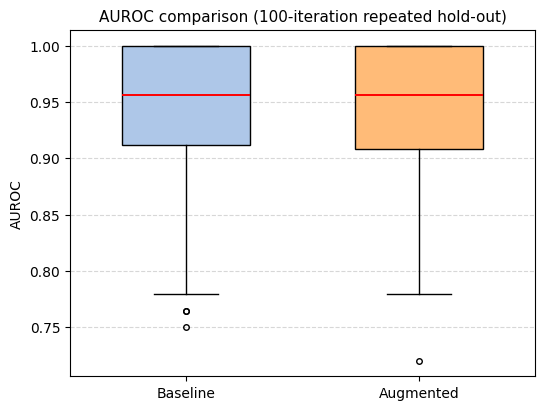

  saved figures/Figure3.pdf / .png


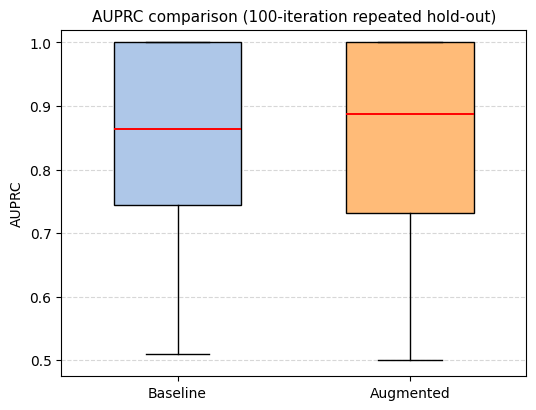

  saved figures/FigureS1_all_metrics.pdf / .png


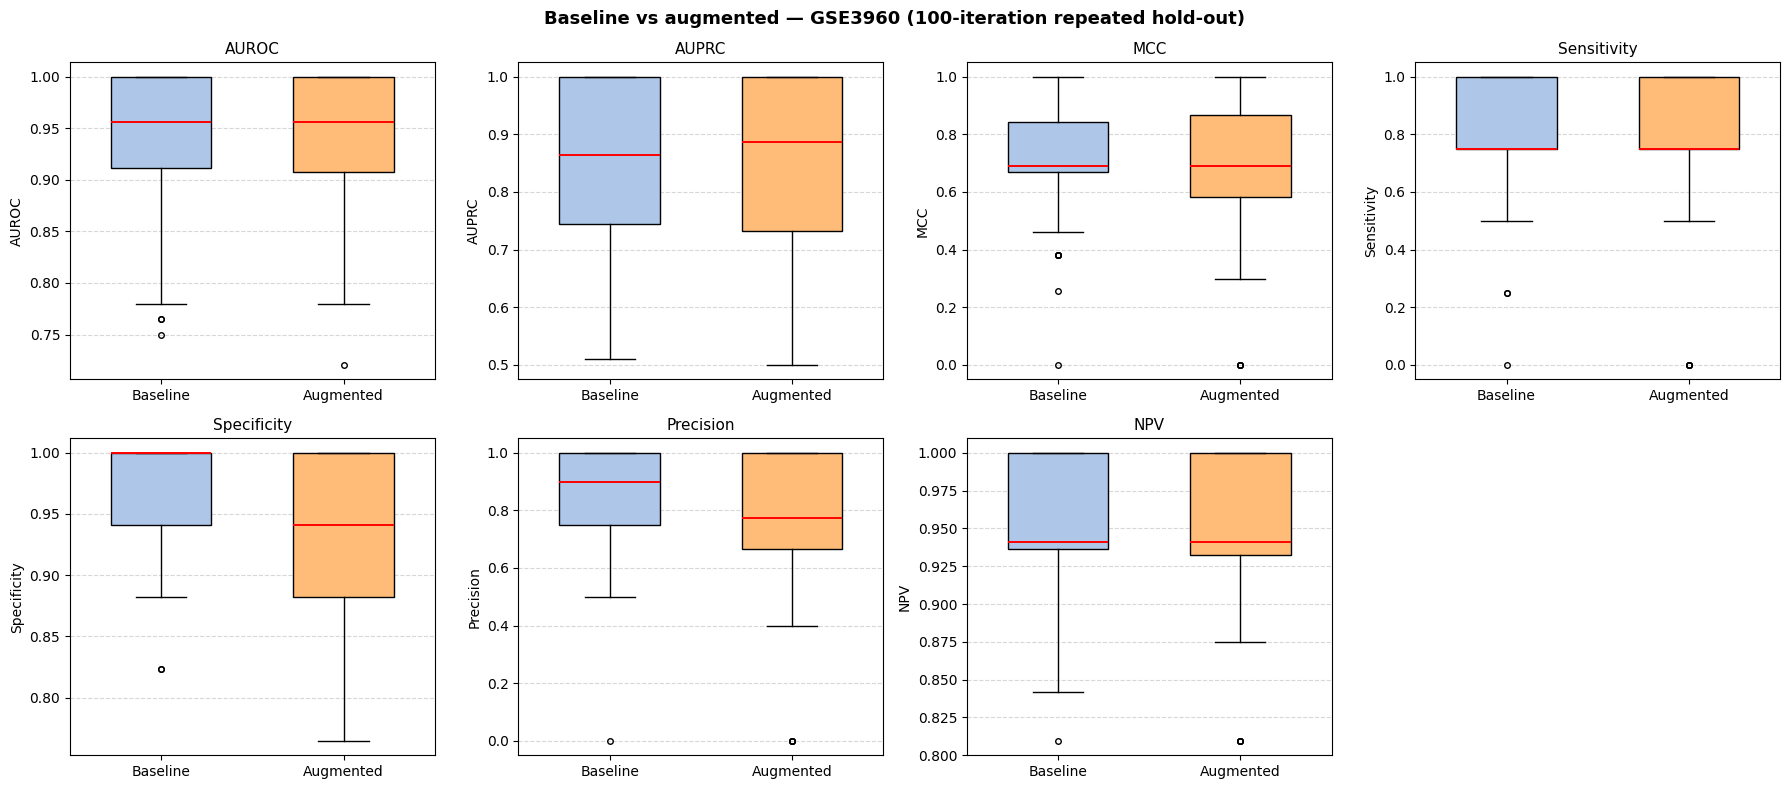

  saved figures/Figure9_ratio_sensitivity.pdf / .png


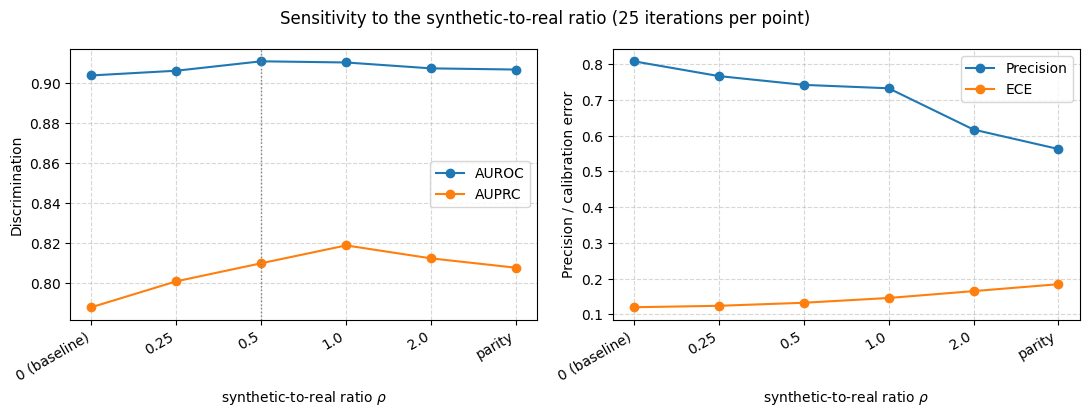


=== Table 3 — repeated hold-out validation (GSE3960) ===


,Model,Metric,count,mean,std,min,25%,50%,75%,max
0,Baseline,AUROC,100.0,0.9354,0.0696,0.7500,0.9118,0.9559,1.0000,1.0000
1,Baseline,AUPRC,100.0,0.8385,0.1452,0.5099,0.7448,0.8646,1.0000,1.0000
2,Baseline,MCC,100.0,0.7420,0.1846,0.0000,0.6689,0.6912,0.8416,1.0000
3,Baseline,Sensitivity,100.0,0.7500,0.2010,0.0000,0.7500,0.7500,1.0000,1.0000
4,Baseline,Specificity,100.0,0.9612,0.0460,0.8235,0.9412,1.0000,1.0000,1.0000
5,Baseline,Precision,100.0,0.8397,0.1888,0.0000,0.7500,0.9000,1.0000,1.0000
6,Baseline,NPV,100.0,0.9442,0.0425,0.8095,0.9365,0.9412,1.0000,1.0000
7,Baseline,ECE,100.0,0.1095,0.0326,0.0481,0.0904,0.1061,0.1238,0.2464
8,Baseline,Brier,100.0,0.0690,0.0331,0.0121,0.0444,0.0655,0.0866,0.1643
9,Augmented,AUROC,100.0,0.9375,0.0677,0.7206,0.9081,0.9559,1.0000,1.0000


  saved figures/table3_gse3960.csv


In [12]:
# ============================================================
# Part 8 — Result figures: discrimination and ratio sensitivity
# ============================================================
# All figures are generated from the checkpointed repeated hold-out results, so
# that every panel and every table entry derive from the same run.

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

BASELINE_COLOUR  = "#aec7e8"
AUGMENTED_COLOUR = "#ffbb78"


def save_figure(fig, name):
    """Write both PDF (for LaTeX inclusion) and PNG (for quick inspection)."""
    for suffix in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", dpi=200, bbox_inches="tight")
    print(f"  saved {FIG_DIR / name}.pdf / .png")


def paired_boxplot(metric, ax):
    """Baseline vs augmented for one metric, on shared folds."""
    data = [cv_df[metric].dropna(), cv_aug[metric].dropna()]
    bp = ax.boxplot(data, tick_labels=["Baseline", "Augmented"],
                    patch_artist=True, widths=0.55,
                    medianprops=dict(color="red", linewidth=1.4),
                    flierprops=dict(marker="o", markersize=4,
                                    markerfacecolor="none"))
    for patch, colour in zip(bp["boxes"], (BASELINE_COLOUR, AUGMENTED_COLOUR)):
        patch.set_facecolor(colour)
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    return ax


# ------------------------------------------------------------
# Figures 2 and 3 — AUROC and AUPRC distributions
# ------------------------------------------------------------
# The y-axis is limited to the observed range rather than anchored at zero:
# fixing it to [0, 1] compresses the distributions into the upper fifth of the
# panel and hides the overlap the figure is meant to show.
for metric, figname in [("auroc", "Figure2"), ("auprc", "Figure3")]:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    paired_boxplot(metric, ax)
    ax.set_title(f"{METRIC_LABELS[metric]} comparison "
                 f"({N_REPEATS}-iteration repeated hold-out)", fontsize=11)
    values = pd.concat([cv_df[metric], cv_aug[metric]]).dropna()
    margin = 0.05 * (values.max() - values.min())
    ax.set_ylim(max(0, values.min() - margin), min(1.02, values.max() + margin))
    save_figure(fig, figname)
    plt.show()

# ------------------------------------------------------------
# Supplementary — all seven metrics on one panel
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, metric in zip(axes.flatten(), ALL_METRICS):
    paired_boxplot(metric, ax)
    ax.set_title(METRIC_LABELS[metric], fontsize=11)
axes.flatten()[7].set_visible(False)
fig.suptitle(f"Baseline vs augmented — GSE3960 "
             f"({N_REPEATS}-iteration repeated hold-out)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, "FigureS1_all_metrics")
plt.show()

# ------------------------------------------------------------
# New figure — synthetic-ratio sensitivity (Section 4.4)
# ------------------------------------------------------------
# Section 4.4 asserts a non-monotone dependence on the synthetic-to-real ratio.
# This panel is the evidence for that claim, which the manuscript previously
# stated without a corresponding experiment.
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(ablation_df))

for ax, metrics, ylabel in [
    (ax_left,  ["auroc", "auprc"],      "Discrimination"),
    (ax_right, ["precision", "ece"],    "Precision / calibration error"),
]:
    for metric in metrics:
        ax.plot(x, ablation_df[metric], marker="o", label=METRIC_LABELS[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(ablation_df.index, rotation=30, ha="right")
    ax.set_xlabel(r"synthetic-to-real ratio $\rho$")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()

ax_left.axvline(list(ablation_df.index).index(str(SYNTH_RATIO)),
                color="grey", linestyle=":", linewidth=1)
fig.suptitle(f"Sensitivity to the synthetic-to-real ratio "
             f"({ABLATION_REPEATS} iterations per point)", fontsize=12)
fig.tight_layout()
save_figure(fig, "Figure9_ratio_sensitivity")
plt.show()

# ------------------------------------------------------------
# Table 3 — repeated hold-out summary
# ------------------------------------------------------------
table3 = pd.concat([
    cv_df[ALL_METRICS + CALIBRATION_METRICS].describe().T.assign(Model="Baseline"),
    cv_aug[ALL_METRICS + CALIBRATION_METRICS].describe().T.assign(Model="Augmented"),
]).reset_index(names="Metric")
table3 = table3[["Model", "Metric", "count", "mean", "std",
                 "min", "25%", "50%", "75%", "max"]]
table3["Metric"] = table3["Metric"].map(METRIC_LABELS)

print("\n=== Table 3 — repeated hold-out validation (GSE3960) ===")
display(table3.round(4))
table3.round(4).to_csv(FIG_DIR / "table3_gse3960.csv", index=False)
print(f"  saved {FIG_DIR / 'table3_gse3960.csv'}")

Mean |SHAP| on the held-out test partition:


,baseline,augmented,direction
1p36_LOH,1.1990,1.3225,1.0
INSS_stage,0.9698,0.9537,1.0
unbalanced11qLOH,0.8748,0.8963,-1.0
age_diagnosis_days,0.6322,0.7150,-1.0
17q_gain,0.4027,0.5977,1.0
1p23_LOH,0.1297,0.2539,-1.0
tumor_percentage,0.0335,0.0440,1.0


  saved figures/Figure5.pdf / .png


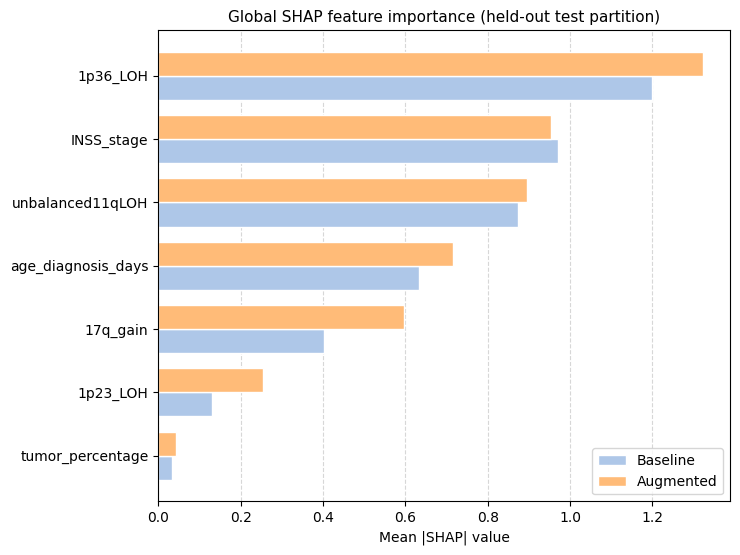


Spearman rank correlation between configurations: 1.000
Highest-attribution predictor: 1p36_LOH (baseline 1.1990, augmented 1.3225)
  saved figures/shap_importances.csv


In [13]:
# ============================================================
# Part 9 — Explainability: SHAP attributions (baseline vs augmented)
# ============================================================
# Section 3.7: SHAP attributions are computed before and after augmentation to
# check that global rankings remain consistent with biomedical knowledge.
# Attributions are evaluated on the held-out test partition, as reported in
# Section 4.3, using the models already fitted in Part 7 rather than refitting
# new ones, so the explained models are the evaluated models.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

TOP_K = None   # all predictors are shown: the cohort has seven, not fifteen


def clean_feature_names(fitted_pre) -> list:
    """Feature names with the ColumnTransformer prefix removed."""
    names = list(fitted_pre.get_feature_names_out())
    return [n.split("__", 1)[-1] for n in names]


def mean_abs_shap(clf, background, X_eval, feature_names) -> pd.Series:
    """Mean absolute SHAP value per feature.

    The interventional perturbation is used so that attributions are not
    distributed across correlated predictors, which Section 2.4 identifies as a
    source of misleading explanations.
    """
    explainer = shap.LinearExplainer(clf, background,
                                     feature_perturbation="interventional")
    values = explainer(X_eval)
    values = values.values if hasattr(values, "values") else values
    return pd.Series(np.abs(values).mean(axis=0), index=feature_names)


# ------------------------------------------------------------
# Attributions for both configurations
# ------------------------------------------------------------
shap_importances, shap_signed = {}, {}

for config, artefacts in SINGLE_MODEL_ARTEFACTS.items():
    fitted_pre, clf = artefacts["pre"], artefacts["clf"]
    names = clean_feature_names(fitted_pre)

    # Background: the training data each model actually saw
    X_bg = X_train_aug if config == "augmented" else X_train
    background = np.asarray(fitted_pre.transform(X_bg), float)
    X_eval = np.asarray(fitted_pre.transform(X_test), float)

    shap_importances[config] = mean_abs_shap(clf, background, X_eval, names)

    # Signed coefficients: direction of effect, which |SHAP| alone does not give
    shap_signed[config] = pd.Series(clf.coef_.ravel(), index=names)

shap_df = pd.DataFrame(shap_importances)
shap_df["direction"] = np.sign(shap_signed["baseline"])
shap_df = shap_df.sort_values("baseline", ascending=False)

print("Mean |SHAP| on the held-out test partition:")
display(shap_df.round(4))

# ------------------------------------------------------------
# Figure 5 — global SHAP importance
# ------------------------------------------------------------
order = shap_df.index[::-1]
positions = np.arange(len(order))
height = 0.38

fig, ax = plt.subplots(figsize=(7.5, 0.55 * len(order) + 1.8))
ax.barh(positions - height / 2, shap_df.loc[order, "baseline"], height,
        label="Baseline", color=BASELINE_COLOUR, edgecolor="white")
ax.barh(positions + height / 2, shap_df.loc[order, "augmented"], height,
        label="Augmented", color=AUGMENTED_COLOUR, edgecolor="white")

ax.set_yticks(positions)
ax.set_yticklabels(order)
ax.set_xlabel("Mean |SHAP| value")
ax.set_title("Global SHAP feature importance (held-out test partition)",
             fontsize=11)
ax.legend()
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "Figure5")
plt.show()

# ------------------------------------------------------------
# Rank agreement between configurations
# ------------------------------------------------------------
# Section 4.3 claims the ranking is preserved under augmentation; the
# correlation makes that claim quantitative rather than visual.
rank_corr = shap_df[["baseline", "augmented"]].corr(method="spearman").iloc[0, 1]
top_feature = shap_df.index[0]
print(f"\nSpearman rank correlation between configurations: {rank_corr:.3f}")
print(f"Highest-attribution predictor: {top_feature} "
      f"(baseline {shap_df.loc[top_feature, 'baseline']:.4f}, "
      f"augmented {shap_df.loc[top_feature, 'augmented']:.4f})")

shap_df.round(4).to_csv(FIG_DIR / "shap_importances.csv")
print(f"  saved {FIG_DIR / 'shap_importances.csv'}")

  saved figures/Figure4.pdf / .png


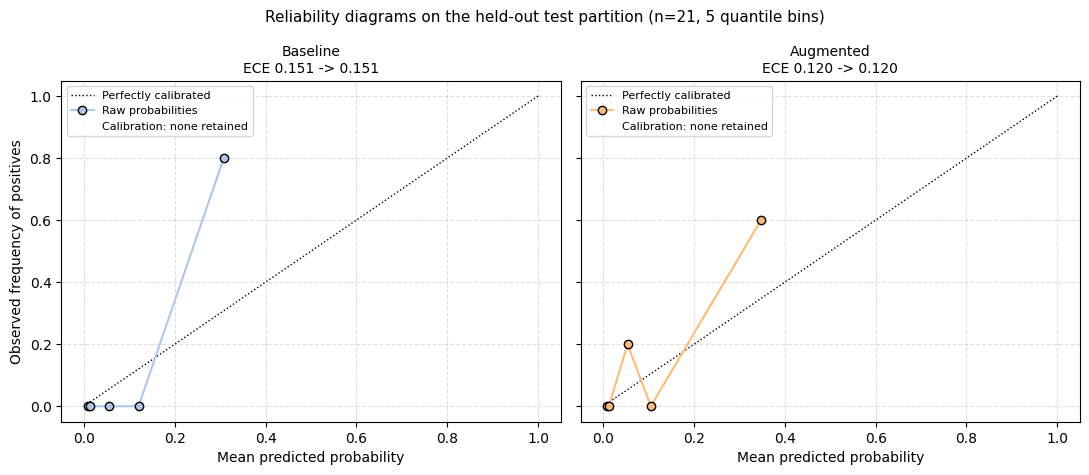

  saved figures/Figure4b_calibration_distributions.pdf / .png


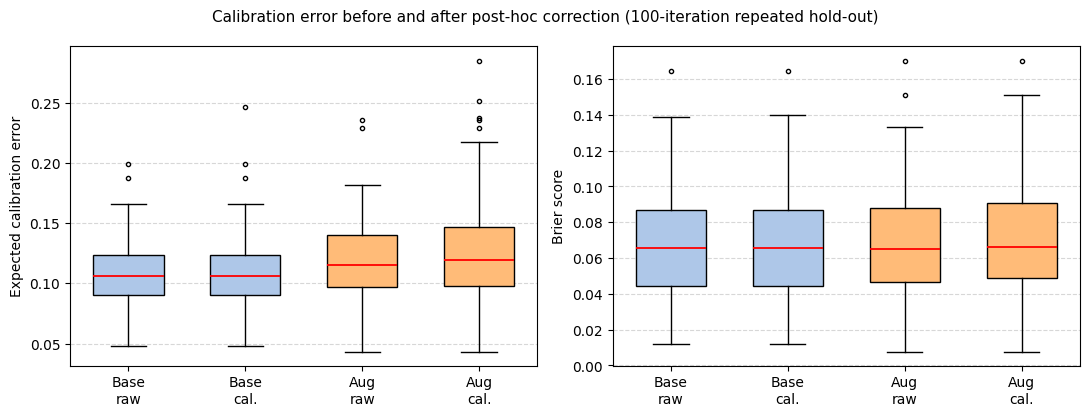

Calibration across the repeated hold-out:


,Baseline,Augmented
ECE raw,0.1086,0.1182
ECE calibrated,0.1095,0.1246
Brier raw,0.0685,0.0702
Brier calibrated,0.0690,0.0734


Baseline: mapping retained {'identity': 99, 'sigmoid': 1}
Augmented: mapping retained {'identity': 96, 'sigmoid': 4}
  saved figures/calibration_summary.csv


In [14]:
# ============================================================
# Part 10 — Probability calibration: reliability and error distributions
# ============================================================
# Section 3.7: calibration is assessed and, where it helps, corrected by Platt
# scaling or isotonic regression selected on validation predictions. The
# selection rule includes leaving the probabilities uncorrected, so the figures
# report the mapping actually retained rather than a fixed choice.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RELIABILITY_BINS = 5   # 21 test patients: ten bins leave ~2 points each, which
                       # forces every bin to 0, 0.5 or 1 and produces a sawtooth
                       # that reflects bin occupancy rather than calibration


def reliability_points(y_true, y_prob, n_bins=RELIABILITY_BINS):
    """Observed frequency against mean predicted probability, using quantile
    bins so that each point rests on a comparable number of patients."""
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()
    edges = np.unique(np.quantile(y_prob, np.linspace(0, 1, n_bins + 1)))
    if edges.size < 2:
        return np.array([]), np.array([]), np.array([])
    idx = np.digitize(y_prob, edges[1:-1], right=False)

    conf, freq, weight = [], [], []
    for b in range(edges.size - 1):
        mask = idx == b
        if not mask.any():
            continue
        conf.append(y_prob[mask].mean())
        freq.append(y_true[mask].mean())
        weight.append(mask.sum())
    return np.array(conf), np.array(freq), np.array(weight)


# ------------------------------------------------------------
# Figure 4 — reliability on the illustrative split
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)

for ax, (config, artefacts) in zip(axes, SINGLE_MODEL_ARTEFACTS.items()):
    colour = BASELINE_COLOUR if config == "baseline" else AUGMENTED_COLOUR
    raw, calibrated, method = (artefacts["proba"], artefacts["calibrated"],
                               artefacts["method"])

    ax.plot([0, 1], [0, 1], "k:", linewidth=1, label="Perfectly calibrated")

    c_raw, f_raw, w_raw = reliability_points(y_test, raw)
    ax.plot(c_raw, f_raw, "o-", color=colour, markeredgecolor="black",
            markersize=6, label="Raw probabilities")

    if method != "identity":
        c_cal, f_cal, _ = reliability_points(y_test, calibrated)
        ax.plot(c_cal, f_cal, "s--", color=colour, alpha=0.6,
                label=f"Calibrated ({method})")
    else:
        ax.plot([], [], " ", label="Calibration: none retained")

    ece_raw = expected_calibration_error(y_test, raw)
    ece_cal = expected_calibration_error(y_test, calibrated)
    ax.set_title(f"{config.capitalize()}\nECE {ece_raw:.3f} -> {ece_cal:.3f}",
                 fontsize=10)
    ax.set_xlabel("Mean predicted probability")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, loc="upper left")

axes[0].set_ylabel("Observed frequency of positives")
fig.suptitle(f"Reliability diagrams on the held-out test partition "
             f"(n={len(y_test)}, {RELIABILITY_BINS} quantile bins)", fontsize=11)
fig.tight_layout()
save_figure(fig, "Figure4")
plt.show()

# ------------------------------------------------------------
# Calibration error across the repeated hold-out
# ------------------------------------------------------------
# A single 21-patient partition cannot establish calibration quality, so the
# claim is supported by the distribution of errors over all iterations.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, metric, label in [(axes[0], "ece", "Expected calibration error"),
                          (axes[1], "brier", "Brier score")]:
    data = [cv_df[f"{metric}_raw"], cv_df[metric],
            cv_aug[f"{metric}_raw"], cv_aug[metric]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6,
                    tick_labels=["Base\nraw", "Base\ncal.",
                                 "Aug\nraw", "Aug\ncal."],
                    medianprops=dict(color="red", linewidth=1.3),
                    flierprops=dict(marker="o", markersize=3,
                                    markerfacecolor="none"))
    for patch, colour in zip(bp["boxes"], [BASELINE_COLOUR, BASELINE_COLOUR,
                                           AUGMENTED_COLOUR, AUGMENTED_COLOUR]):
        patch.set_facecolor(colour)
    ax.set_ylabel(label)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle(f"Calibration error before and after post-hoc correction "
             f"({N_REPEATS}-iteration repeated hold-out)", fontsize=11)
fig.tight_layout()
save_figure(fig, "Figure4b_calibration_distributions")
plt.show()

# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------
calibration_summary = pd.DataFrame({
    "Baseline": [cv_df["ece_raw"].mean(), cv_df["ece"].mean(),
                 cv_df["brier_raw"].mean(), cv_df["brier"].mean()],
    "Augmented": [cv_aug["ece_raw"].mean(), cv_aug["ece"].mean(),
                  cv_aug["brier_raw"].mean(), cv_aug["brier"].mean()],
}, index=["ECE raw", "ECE calibrated", "Brier raw", "Brier calibrated"])

print("Calibration across the repeated hold-out:")
display(calibration_summary.round(4))

for name, results in [("Baseline", cv_df), ("Augmented", cv_aug)]:
    counts = results["calibration_method"].value_counts().to_dict()
    print(f"{name}: mapping retained {counts}")

calibration_summary.round(4).to_csv(FIG_DIR / "calibration_summary.csv")
print(f"  saved {FIG_DIR / 'calibration_summary.csv'}")

Reusing checkpointed distances (264 values).
  saved figures/Figure6.pdf / .png


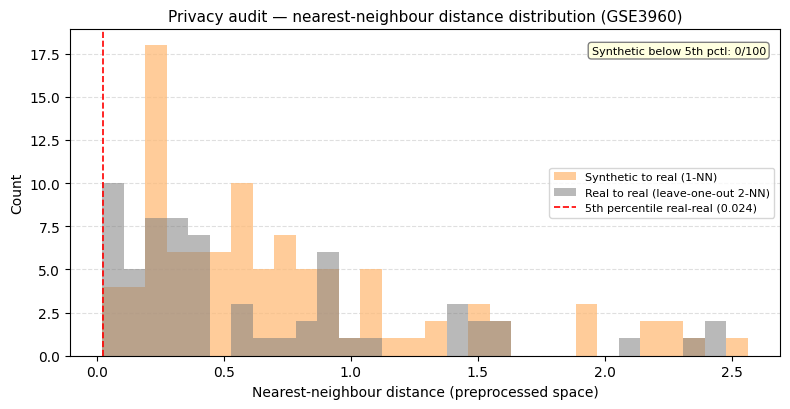

DP-lite sanitisation (k>=3, Laplace eps=8.0):
  median distance to closest real record: 0.5490 -> 0.6274
  rows below the real-real 5th percentile: 0 -> 2 of 100

Reusing checkpointed DP sweep (25 iterations).

DP sweep: 25 hold-out iterations x 5 budgets (k = 7 features retained)

=== Table 4 — privacy-utility operating points (GSE3960) ===


,AUROC,AUPRC,MCC,Sensitivity,ece_post,brier_post
epsilon,,,,,,
$\infty$,0.9165 ± 0.0753,0.8352 ± 0.1242,0.6973 ± 0.1557,0.6600 ± 0.2380,0.1314 ± 0.0275,0.0766 ± 0.0217
16,0.9118 ± 0.0770,0.8350 ± 0.1174,0.6540 ± 0.2382,0.6300 ± 0.2712,0.1330 ± 0.0278,0.0771 ± 0.0224
8,0.9206 ± 0.0683,0.8299 ± 0.1220,0.6377 ± 0.2303,0.6300 ± 0.2712,0.1387 ± 0.0399,0.0802 ± 0.0258
4,0.8971 ± 0.0789,0.7504 ± 0.1345,0.4830 ± 0.2619,0.4800 ± 0.2693,0.1428 ± 0.0452,0.0981 ± 0.0343
2,0.7771 ± 0.1690,0.5832 ± 0.2555,0.4034 ± 0.3437,0.4600 ± 0.2947,0.1751 ± 0.0816,0.1281 ± 0.0479


  saved figures/Figure7.pdf / .png


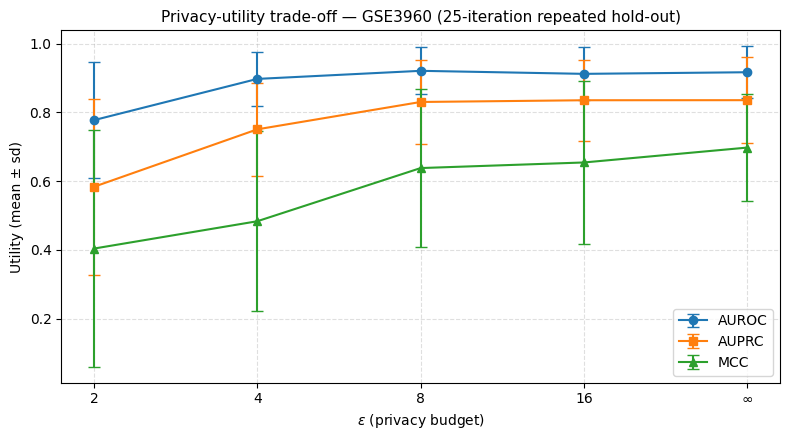

In [15]:
# ============================================================
# Part 11 — Privacy: empirical audit and differentially private learning
# ============================================================
# Section 3.6: privacy is treated as a measurable property. The empirical audit
# quantifies memorisation risk in the synthetic data; the differentially private
# logistic regression provides formal (epsilon, 0)-DP operating points through
# objective perturbation. DP models are trained on real data only: synthetic
# records never enter the privacy-utility analysis.
#
# The sweep is evaluated under the same repeated hold-out used for the main
# results, so that the reported variability reflects both the DP mechanism and
# the partitioning of a small cohort, rather than the mechanism alone.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import NearestNeighbors
from diffprivlib.models import LogisticRegression as DpLogReg

EPS_GRID = [np.inf, 16.0, 8.0, 4.0, 2.0]
DP_REPEATS = 25
DATA_NORM = 1.0
K_SUPPRESSION = 3
DP_LITE_EPSILON = 8.0

# ------------------------------------------------------------
# Distances for Figure 6
# ------------------------------------------------------------
# The per-fold audit stores summary statistics only, so the distance vectors for
# one representative fold are computed once and checkpointed: the figure needs
# the distances, not the generator, and refitting CTGAN to redraw a plot would
# cost minutes for no additional information.
_distances = load_checkpoint("figure6_distances")

if _distances is None:
    from sdv.single_table import CTGANSynthesizer
    from sdv.sampling import Condition

    _real_fold = X_train.copy()
    _real_fold[TARGET_COLUMN] = y_train.values
    set_all_seeds(RANDOM_SEED)
    _gen = CTGANSynthesizer(metadata=build_metadata(_real_fold),
                            **{k: v for k, v in GEN_CONFIG.items() if k != "name"})
    _gen.fit(_real_fold)
    _pool = _gen.sample_from_conditions(
        [Condition(num_rows=AUDIT_N_SAMPLES, column_values={TARGET_COLUMN: 1})]
    )[_real_fold.columns].drop(columns=[TARGET_COLUMN])

    _tr = clone(pre).fit(X_train)
    _real_t = np.asarray(_tr.transform(X_train), float)
    _nn = NearestNeighbors(n_neighbors=2).fit(_real_t)

    d_syn = _nn.kneighbors(np.asarray(_tr.transform(_pool), float),
                           n_neighbors=1)[0].ravel()
    d_real = _nn.kneighbors(_real_t, n_neighbors=2)[0][:, 1]   # leave-one-out

    # DP-lite sanitisation: a non-composed preprocessing safeguard applied to the
    # released synthetic table only. It does not enter the reported models, and
    # its effect on the distance distribution is quantified rather than assumed.
    synthetic_release = _pool.copy()
    _rng = np.random.default_rng(RANDOM_SEED)
    for col in synthetic_release.columns:
        if col in CONTINUOUS_COLUMNS:
            lo, hi = X_train[col].min(), X_train[col].max()
            scale = max(hi - lo, 1e-6) / DP_LITE_EPSILON
            synthetic_release[col] = np.clip(
                synthetic_release[col] + _rng.laplace(0.0, scale,
                                                      len(synthetic_release)), lo, hi)
        else:
            counts = synthetic_release[col].value_counts()
            rare = counts[counts < K_SUPPRESSION].index
            if len(rare):
                synthetic_release.loc[synthetic_release[col].isin(rare), col] = \
                    X_train[col].mode().iloc[0]

    d_release = _nn.kneighbors(
        np.asarray(_tr.transform(synthetic_release), float), n_neighbors=1)[0].ravel()

    _distances = pd.DataFrame({
        "distance": np.concatenate([d_syn, d_real, d_release]),
        "source": (["synthetic"] * len(d_syn) + ["real"] * len(d_real)
                   + ["sanitised"] * len(d_release)),
    })
    save_checkpoint("figure6_distances", _distances)
else:
    print(f"Reusing checkpointed distances ({len(_distances)} values).")

d_syn = _distances.query("source == 'synthetic'")["distance"].to_numpy()
d_real = _distances.query("source == 'real'")["distance"].to_numpy()
d_release = _distances.query("source == 'sanitised'")["distance"].to_numpy()
p5_real = np.percentile(d_real, AUDIT_CONFIG["dcr_percentile"])
n_below = int((d_syn < p5_real).sum())

# ------------------------------------------------------------
# Figure 6 — nearest-neighbour distance distribution
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.histogram_bin_edges(np.concatenate([d_syn, d_real]), bins=30)
ax.hist(d_syn, bins=bins, alpha=0.75, color=AUGMENTED_COLOUR,
        label="Synthetic to real (1-NN)")
ax.hist(d_real, bins=bins, alpha=0.55, color="grey",
        label="Real to real (leave-one-out 2-NN)")
ax.axvline(p5_real, color="red", linestyle="--", linewidth=1.2,
           label=f"5th percentile real-real ({p5_real:.3f})")
ax.set_xlabel("Nearest-neighbour distance (preprocessed space)")
ax.set_ylabel("Count")
ax.set_title("Privacy audit — nearest-neighbour distance distribution (GSE3960)",
             fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.text(0.98, 0.95, f"Synthetic below 5th pctl: {n_below}/{len(d_syn)}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="grey"))
fig.tight_layout()
save_figure(fig, "Figure6")
plt.show()

print(f"DP-lite sanitisation (k>={K_SUPPRESSION}, Laplace eps={DP_LITE_EPSILON}):")
print(f"  median distance to closest real record: "
      f"{np.median(d_syn):.4f} -> {np.median(d_release):.4f}")
print(f"  rows below the real-real 5th percentile: "
      f"{n_below} -> {int((d_release < p5_real).sum())} of {len(d_syn)}")

# ------------------------------------------------------------
# Privacy-utility sweep under repeated hold-out (Table 4, Figure 7)
# ------------------------------------------------------------
# Uniform preprocessing across cohorts: SelectKBest(k = min(15, p)) followed by
# per-sample L2 normalisation, which bounds ||x||_2 <= 1 and justifies
# data_norm = 1.0 for the objective-perturbation mechanism. Feature selection is
# refitted inside each iteration on the training partition only.
def fit_dp_model(eps, X_fit, y_fit, seed):
    """Objective-perturbation logistic regression, or its non-private
    counterpart when the budget is unbounded."""
    np.random.seed(seed)
    model = (SkLogReg(max_iter=2000) if np.isinf(eps)
             else DpLogReg(epsilon=float(eps), data_norm=DATA_NORM,
                           C=1.0, max_iter=2000))
    return model.fit(X_fit, y_fit)


dp_runs = load_checkpoint("dp_runs")

if dp_runs is not None:
    print(f"\nReusing checkpointed DP sweep "
          f"({dp_runs['iteration'].nunique()} iterations).")
else:
    dp_rows = []
    _splitter = StratifiedShuffleSplit(n_splits=DP_REPEATS,
                                       test_size=HOLDOUT_TEST_SIZE,
                                       random_state=RANDOM_SEED)

    for i, (tr_idx, te_idx) in enumerate(_splitter.split(X, y), 1):
        seed_i = RANDOM_SEED + i
        X_tr_full, y_tr_full = X.iloc[tr_idx], y.iloc[tr_idx]
        X_te_i,    y_te_i    = X.iloc[te_idx], y.iloc[te_idx]

        pre_i = clone(pre).fit(X_tr_full)
        Xtr_i = np.asarray(pre_i.transform(X_tr_full), float)
        Xte_i = np.asarray(pre_i.transform(X_te_i), float)
        y_tr_i, y_te_i = np.asarray(y_tr_full).ravel(), np.asarray(y_te_i).ravel()

        k_sel = min(15, Xtr_i.shape[1])
        sel_i = SelectKBest(mutual_info_classif, k=k_sel).fit(Xtr_i, y_tr_i)
        Xtr_i = normalize(sel_i.transform(Xtr_i), norm="l2")
        Xte_i = normalize(sel_i.transform(Xte_i), norm="l2")

        idx_fit, idx_val = next(StratifiedShuffleSplit(
            n_splits=1, test_size=INTERNAL_VAL_SIZE,
            random_state=seed_i).split(Xtr_i, y_tr_i))

        for eps in EPS_GRID:
            model = fit_dp_model(eps, Xtr_i, y_tr_i, seed_i)
            proba = model.predict_proba(Xte_i)[:, 1]

            inner = fit_dp_model(eps, Xtr_i[idx_fit], y_tr_i[idx_fit], seed_i)
            calibrate, method = select_calibrator(
                y_tr_i[idx_val], inner.predict_proba(Xtr_i[idx_val])[:, 1])
            calibrated = compute_all_metrics(y_te_i, np.clip(calibrate(proba), 0, 1))

            dp_rows.append({"epsilon": eps, "iteration": i, "k_selected": k_sel,
                            **compute_all_metrics(y_te_i, proba),
                            "ece_post": calibrated["ece"],
                            "brier_post": calibrated["brier"],
                            "calibration": method})

    dp_runs = pd.DataFrame(dp_rows)
    save_checkpoint("dp_runs", dp_runs)

print(f"\nDP sweep: {dp_runs['iteration'].nunique()} hold-out iterations x "
      f"{len(EPS_GRID)} budgets "
      f"(k = {dp_runs['k_selected'].mode().iloc[0]} features retained)")

_metrics = ALL_METRICS + ["ece", "ece_post", "brier", "brier_post"]
dp_summary = dp_runs.groupby("epsilon")[_metrics].agg(["mean", "std"])
dp_summary = dp_summary.sort_index(
    key=lambda s: s.map(lambda e: 1e9 if np.isinf(e) else e), ascending=False)

table4 = pd.DataFrame({
    METRIC_LABELS.get(m, m): [f"{dp_summary.loc[e, (m, 'mean')]:.4f} ± "
                              f"{dp_summary.loc[e, (m, 'std')]:.4f}"
                              for e in dp_summary.index]
    for m in ["auroc", "auprc", "mcc", "sensitivity", "ece_post", "brier_post"]
}, index=[r"$\infty$" if np.isinf(e) else f"{e:.0f}" for e in dp_summary.index])
table4.index.name = "epsilon"

print("\n=== Table 4 — privacy-utility operating points (GSE3960) ===")
display(table4)
table4.to_csv(FIG_DIR / "table4_dp_gse3960.csv")

# ------------------------------------------------------------
# Figure 7 — utility against the privacy budget
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
finite = sorted(e for e in dp_summary.index if not np.isinf(e))
positions = {e: i for i, e in enumerate(finite + [np.inf])}
for metric, marker in [("auroc", "o"), ("auprc", "s"), ("mcc", "^")]:
    ax.errorbar([positions[e] for e in dp_summary.index],
                dp_summary[(metric, "mean")], yerr=dp_summary[(metric, "std")],
                marker=marker, capsize=4, label=METRIC_LABELS[metric])
ax.set_xticks(list(positions.values()))
ax.set_xticklabels([f"{e:.0f}" for e in finite] + [r"$\infty$"])
ax.set_xlabel(r"$\varepsilon$ (privacy budget)")
ax.set_ylabel("Utility (mean ± sd)")
ax.set_title(f"Privacy-utility trade-off — GSE3960 "
             f"({dp_runs['iteration'].nunique()}-iteration repeated hold-out)",
             fontsize=11)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "Figure7")
plt.show()

MANIFEST["differential_privacy"] = {
    "mechanism": "objective perturbation (Chaudhuri et al. 2011, diffprivlib Vector)",
    "epsilon_grid": [str(e) for e in EPS_GRID],
    "n_repeats": DP_REPEATS,
    "k_selected": int(dp_runs["k_selected"].mode().iloc[0]),
    "data_norm": DATA_NORM,
}

[dataYM2018 (Shanghai)] dropped 4 row(s) without an outcome
[dataYM2018 (Shanghai)] target coding inverted
[dataYM2018 (Shanghai)] n=169, features=10, class 0=124, class 1=45, prevalence=0.266
[dataYM2018 (Shanghai)] minority rows per training fold ~29, synthetic rows at rho=0.5 ~14
[dataYM2018 (Shanghai)] reusing checkpointed results (100 iterations)


Sampling conditions: 100%|██████████| 14/14 [00:00<00:00, 121.11it/s]


[dataYM2018 (Shanghai) augmented] fold 13: AUROC 0.1711 -> 0.8556 (sigmoid -> sigmoid)


Sampling conditions: 100%|██████████| 14/14 [00:00<00:00, 125.49it/s]


[dataYM2018 (Shanghai) augmented] fold 43: AUROC 0.8178 -> 0.8489 (sigmoid -> identity)
  saved checkpoints/shanghai_augmented.parquet (18 KB)
TCGA-ACC merged shape: (92, 84)
[TCGA-ACC] dropped 8 constant column(s)
[TCGA-ACC] n=92, features=38, class 0=58, class 1=34, prevalence=0.370
[TCGA-ACC] minority rows per training fold ~22, synthetic rows at rho=0.5 ~11
[TCGA-ACC (Adrenocortical)] reusing checkpointed results (100 iterations)


...

[TCGA-ACC (Adrenocortical) augmented] fold 27: AUROC 0.1190 -> 0.8571 (sigmoid -> sigmoid)
  saved checkpoints/tcga_augmented.parquet (17 KB)
GSE3960     baseline   0 fold(s) with an altered ranking
GSE3960     augmented  0 fold(s) with an altered ranking
dataYM2018  baseline   0 fold(s) with an altered ranking
dataYM2018  augmented  0 fold(s) with an altered ranking
TCGA-ACC    baseline   0 fold(s) with an altered ranking
TCGA-ACC    augmented  0 fold(s) with an altered ranking

=== Table 5 — cross-dataset comparison ===


,Dataset,Disease,N,Feat.,Config.,AUROC,AUPRC,MCC
0,GSE3960,Neuroblastoma,101,7,Baseline,0.9354 ± 0.0696,0.8385 ± 0.1452,0.7420 ± 0.1846
1,GSE3960,Neuroblastoma,101,7,Augmented,0.9375 ± 0.0677,0.8436 ± 0.1407,0.7068 ± 0.2233
2,,,,,Δ,+0.0021,+0.0051,-0.0352
3,dataYM2018 (Shanghai),Neuroblastoma,169,10,Baseline,0.8425 ± 0.0702,0.6774 ± 0.1250,0.4116 ± 0.1847
4,dataYM2018 (Shanghai),Neuroblastoma,169,10,Augmented,0.8258 ± 0.0826,0.6621 ± 0.1330,0.4117 ± 0.2101
5,,,,,Δ,-0.0167,-0.0153,+0.0001
6,TCGA-ACC (Adrenocortical),Adrenocortical carcinoma,92,38,Baseline,0.7770 ± 0.1026,0.7090 ± 0.1289,0.3254 ± 0.2518
7,TCGA-ACC (Adrenocortical),Adrenocortical carcinoma,92,38,Augmented,0.7807 ± 0.0996,0.7154 ± 0.1314,0.3005 ± 0.2527
8,,,,,Δ,+0.0037,+0.0064,-0.0249


[dataYM2018] DP sweep: 25 iterations, k=10 retained
[TCGA-ACC] DP sweep: 25 iterations, k=15 retained
  saved checkpoints/dp_cross_dataset.parquet (33 KB)

=== Table 6 — privacy-utility operating points across cohorts ===


,GSE3960,dataYM2018,TCGA-ACC,TCGA-ACC (naive)
epsilon,,,,
$\infty$,0.9165 ± 0.0753,0.8293 ± 0.0785,0.7538 ± 0.1060,0.7886 ± 0.1083
16,0.9118 ± 0.0770,0.8286 ± 0.0734,0.7210 ± 0.1301,0.6076 ± 0.1332
8,0.9206 ± 0.0683,0.7861 ± 0.1077,0.7186 ± 0.1377,0.5229 ± 0.0926
4,0.8971 ± 0.0789,0.7564 ± 0.0945,0.6552 ± 0.1822,0.4824 ± 0.0578
2,0.7771 ± 0.1690,0.6620 ± 0.1418,0.5833 ± 0.1736,0.5060 ± 0.2022


  saved figures/Figure8.pdf / .png


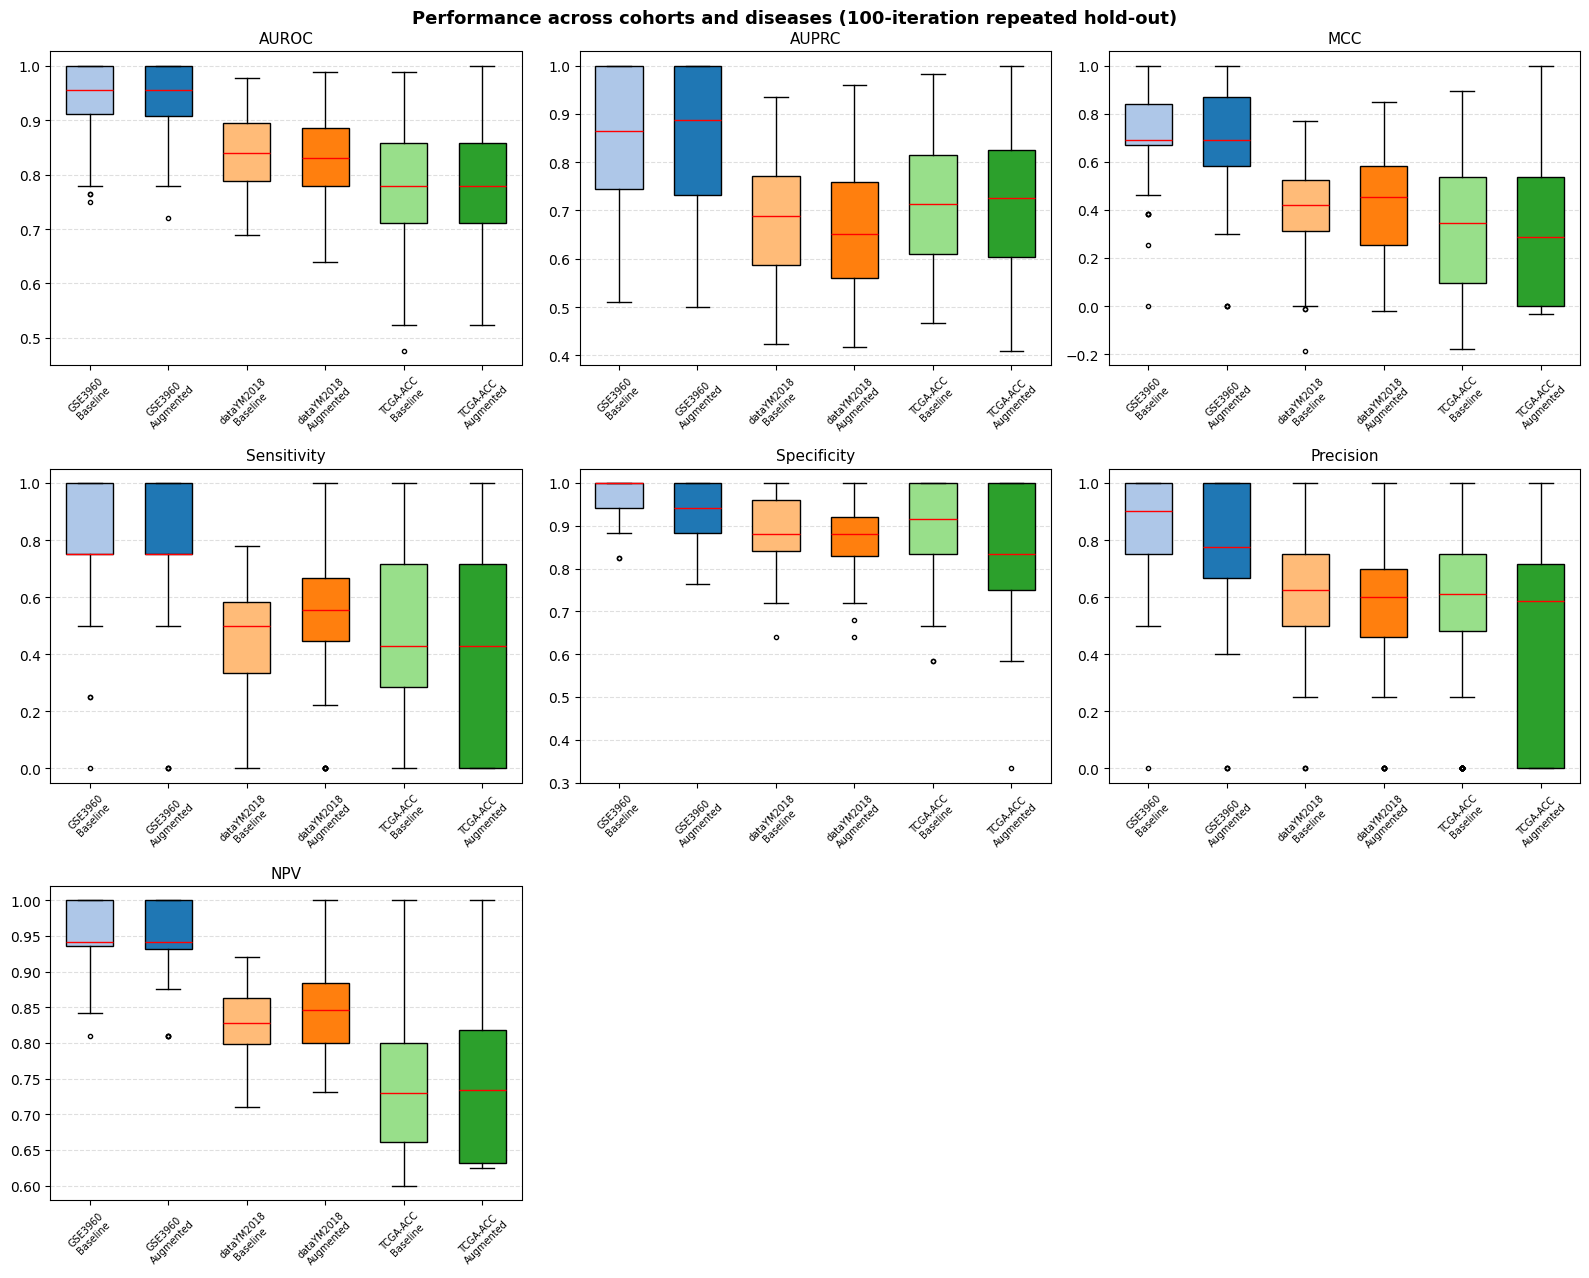

In [17]:
# ============================================================
# Part 12 — External validation: cross-cohort and cross-disease
# ============================================================
# The same protocol is applied to each additional cohort without site-specific
# tuning, as declared in Section 4.5: 100-iteration repeated hold-out, 80/20
# stratified split, identical generator settings. The pipeline is parameterised
# by cohort so that no cohort overwrites the state of another.
#
# Results already on disk are reused. Folds in which the post-hoc calibration
# altered the ranking of the patients are recomputed individually with the
# corrected selection rule, so a full re-execution is not required.

import os, time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from contextlib import contextmanager
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.model_selection import StratifiedShuffleSplit
from diffprivlib.models import LogisticRegression as DpLogReg

N_JOBS = min(8, os.cpu_count())

COHORT_RESULTS = {"GSE3960": {
    "label": "GSE3960", "disease": "Neuroblastoma",
    "n": len(df), "n_features": X.shape[1],
    "baseline": cv_df, "augmented": cv_aug, "audit": audit_df,
    "X": X, "y": y,
}}


@contextmanager
def cohort_context(target_column, continuous_columns, preprocessor,
                   numeric, categorical):
    """Temporarily point the shared pipeline helpers at a different cohort.

    The augmentation and audit functions read the cohort configuration from
    module scope; rebinding it inside a context manager keeps each cohort
    isolated and restores the primary configuration on exit.
    """
    global TARGET_COLUMN, CONTINUOUS_COLUMNS, pre, num_cols, cat_cols
    saved = (TARGET_COLUMN, CONTINUOUS_COLUMNS, pre, num_cols, cat_cols)
    TARGET_COLUMN, CONTINUOUS_COLUMNS = target_column, continuous_columns
    pre, num_cols, cat_cols = preprocessor, numeric, categorical
    try:
        yield
    finally:
        (TARGET_COLUMN, CONTINUOUS_COLUMNS, pre, num_cols, cat_cols) = saved


def prepare_cohort(frame, target_column, label, flip_target=False,
                   drop_columns=None):
    """Clean a cohort and return (X, y) under the primary cohort's conventions."""
    frame = frame.copy()
    frame.columns = [c.strip() for c in frame.columns]

    for col in frame.columns:                       # sentinel handling
        if frame[col].dtype == "object":
            mask = frame[col].astype(str).str.strip().isin(_SENTINELS)
            frame[col] = frame[col].where(~mask, np.nan)
            converted = pd.to_numeric(frame[col], errors="coerce")
            if converted.notna().sum() == frame[col].notna().sum():
                frame[col] = converted

    if drop_columns:
        frame = frame.drop(columns=[c for c in drop_columns if c in frame.columns])

    # Rows without an outcome are removed rather than imputed: imputing a label
    # would fabricate the quantity the model is evaluated against.
    n_before = len(frame)
    frame = frame.dropna(subset=[target_column]).reset_index(drop=True)
    if len(frame) < n_before:
        print(f"[{label}] dropped {n_before - len(frame)} row(s) without an outcome")

    y_c = pd.to_numeric(frame[target_column], errors="coerce").astype(int)
    if flip_target:
        y_c = 1 - y_c
        print(f"[{label}] target coding inverted")
    X_c = frame.drop(columns=[target_column])

    # Constant columns carry no signal and inflate the generator's input space
    constant = [c for c in X_c.columns if X_c[c].nunique(dropna=True) <= 1]
    if constant:
        X_c = X_c.drop(columns=constant)
        print(f"[{label}] dropped {len(constant)} constant column(s)")

    counts = y_c.value_counts().sort_index()
    minority_fold = int(round(min(counts) * (1 - HOLDOUT_TEST_SIZE)
                              * (1 - INTERNAL_VAL_SIZE)))
    print(f"[{label}] n={len(y_c)}, features={X_c.shape[1]}, "
          f"class 0={counts.get(0, 0)}, class 1={counts.get(1, 0)}, "
          f"prevalence={y_c.mean():.3f}")
    print(f"[{label}] minority rows per training fold ~{minority_fold}, "
          f"synthetic rows at rho={SYNTH_RATIO} ~{round(SYNTH_RATIO * minority_fold)}")
    return X_c, y_c


def cohort_preprocessor(X_c):
    """Preprocessor for a cohort, reusing the imputer chosen on GSE3960.

    Section 4.5 requires the same pipeline without site-specific tuning, so the
    imputer is not re-ranked per cohort.
    """
    numeric = [c for c in X_c.columns if pd.api.types.is_numeric_dtype(X_c[c])]
    categorical = [c for c in X_c.columns if c not in numeric]
    global num_cols, cat_cols
    saved = (num_cols, cat_cols)
    num_cols, cat_cols = numeric, categorical
    built = build_preprocessor(BEST_IMPUTER)
    num_cols, cat_cols = saved
    return built, numeric, categorical


def repair_inverted_folds(frame, X_c, y_c, target_column, continuous_columns,
                          label, augmented):
    """Recompute the folds in which the calibration reordered the patients.

    AUROC is invariant under a monotone increasing calibration, so a fold where
    the calibrated and uncalibrated values differ was mapped by a function that
    inverted the ranking. Those folds are recomputed with the corrected rule,
    while the remaining folds are left untouched.
    """
    broken = frame.index[(frame["auroc"] - frame["auroc_raw"]).abs() > 1e-9]
    if len(broken) == 0:
        return frame, 0

    splits = list(StratifiedShuffleSplit(
        n_splits=len(frame), test_size=HOLDOUT_TEST_SIZE,
        random_state=RANDOM_SEED).split(X_c, y_c))
    pre_c, numeric, categorical = cohort_preprocessor(X_c)
    augment = make_augment_fn(SYNTH_RATIO, audit=False) if augmented else None

    for pos in broken:
        i = int(frame.loc[pos, "iteration"])
        tr_idx, te_idx = splits[i - 1]
        with cohort_context(target_column, continuous_columns, pre_c,
                            numeric, categorical):
            row, _ = _run_iteration(i, tr_idx, te_idx, X_c, y_c, augment)
        print(f"[{label}] fold {i}: AUROC {frame.loc[pos, 'auroc']:.4f} -> "
              f"{row['auroc']:.4f} ({frame.loc[pos, 'calibration_method']} -> "
              f"{row['calibration_method']})")
        for col, value in row.items():
            if col in frame.columns:
                frame.loc[pos, col] = value

    return frame, len(broken)


def run_cohort(X_c, y_c, target_column, label, disease, continuous_columns,
               key, n_repeats=None):
    """Baseline and augmented repeated hold-out for one cohort.

    Checkpointed results are reused when available, and any fold affected by an
    inverted calibration is recomputed before the results are returned.
    """
    n_repeats = n_repeats or N_REPEATS
    pre_c, numeric, categorical = cohort_preprocessor(X_c)

    cached = {name: load_checkpoint(f"{key}_{name}")
              for name in ("baseline", "augmented", "audit")}

    if all(value is not None for value in cached.values()):
        print(f"[{label}] reusing checkpointed results "
              f"({len(cached['baseline'])} iterations)")
        baseline, augmented, audit = (cached["baseline"], cached["augmented"],
                                      cached["audit"])
        for name, frame, is_aug in [("baseline", baseline, False),
                                    ("augmented", augmented, True)]:
            frame, repaired = repair_inverted_folds(
                frame, X_c, y_c, target_column, continuous_columns,
                f"{label} {name}", is_aug)
            if repaired:
                save_checkpoint(f"{key}_{name}", frame)
            if name == "baseline":
                baseline = frame
            else:
                augmented = frame
    else:
        t0 = time.time()
        with cohort_context(target_column, continuous_columns, pre_c,
                            numeric, categorical):
            n_probe = int(len(X_c) * (1 - HOLDOUT_TEST_SIZE) * (1 - INTERNAL_VAL_SIZE))
            t_probe = time.time()
            make_augment_fn(SYNTH_RATIO, audit=False)(
                X_c.iloc[:n_probe], y_c.iloc[:n_probe], seed=RANDOM_SEED)
            probe = time.time() - t_probe
            print(f"[{label}] single generator fit: {probe:.0f}s "
                  f"(projected: {probe * n_repeats / 60 / N_JOBS:.0f} min)")

            baseline, _ = run_repeated_holdout(
                X_c, y_c, n_repeats=n_repeats, label=f"{label} baseline")
            augmented, audit = run_repeated_holdout(
                X_c, y_c, n_repeats=n_repeats,
                augment_fn=make_augment_fn(SYNTH_RATIO),
                label=f"{label} augmented (CTGAN, rho={SYNTH_RATIO})")
        print(f"[{label}] completed in {(time.time() - t0) / 60:.1f} min")
        for name, frame in [("baseline", baseline), ("augmented", augmented),
                            ("audit", audit)]:
            save_checkpoint(f"{key}_{name}", frame)

    return {"label": label, "disease": disease, "n": len(y_c),
            "n_features": X_c.shape[1], "baseline": baseline,
            "augmented": augmented, "audit": audit, "X": X_c, "y": y_c}


def dp_sweep(X_c, y_c, label, n_repeats=25):
    """Privacy-utility operating points under the uniform DP preprocessing."""
    pre_c, _, _ = cohort_preprocessor(X_c)
    rows = []
    splitter = StratifiedShuffleSplit(n_splits=n_repeats,
                                      test_size=HOLDOUT_TEST_SIZE,
                                      random_state=RANDOM_SEED)
    for i, (tr_idx, te_idx) in enumerate(splitter.split(X_c, y_c), 1):
        seed_i = RANDOM_SEED + i
        p_i = clone(pre_c).fit(X_c.iloc[tr_idx])
        Xtr_i = np.asarray(p_i.transform(X_c.iloc[tr_idx]), float)
        Xte_i = np.asarray(p_i.transform(X_c.iloc[te_idx]), float)
        ytr_i = np.asarray(y_c.iloc[tr_idx]).ravel()
        yte_i = np.asarray(y_c.iloc[te_idx]).ravel()

        k_sel = min(15, Xtr_i.shape[1])
        sel = SelectKBest(mutual_info_classif, k=k_sel).fit(Xtr_i, ytr_i)
        Xtr_n = normalize(sel.transform(Xtr_i), norm="l2")
        Xte_n = normalize(sel.transform(Xte_i), norm="l2")

        for eps in EPS_GRID:
            np.random.seed(seed_i)
            model = (SkLogReg(max_iter=2000) if np.isinf(eps)
                     else DpLogReg(epsilon=float(eps), data_norm=DATA_NORM,
                                   C=1.0, max_iter=2000))
            model.fit(Xtr_n, ytr_i)
            rows.append({"epsilon": eps, "iteration": i, "strategy": "Mitigated",
                         "k_selected": k_sel,
                         **compute_all_metrics(yte_i, model.predict_proba(Xte_n)[:, 1])})

            # Naive comparator: full feature space, empirical norm bound. Retained
            # because Section 4.5 contrasts it with the mitigated strategy.
            if label == "TCGA-ACC":
                dn = max(float(np.percentile(np.linalg.norm(Xtr_i, axis=1), 95)), 1.0)
                naive = (SkLogReg(max_iter=2000) if np.isinf(eps)
                         else DpLogReg(epsilon=float(eps), data_norm=dn,
                                       C=1.0, max_iter=2000))
                naive.fit(Xtr_i, ytr_i)
                rows.append({"epsilon": eps, "iteration": i, "strategy": "Naive",
                             "k_selected": Xtr_i.shape[1],
                             **compute_all_metrics(yte_i,
                                                   naive.predict_proba(Xte_i)[:, 1])})
    frame = pd.DataFrame(rows)
    print(f"[{label}] DP sweep: {n_repeats} iterations, "
          f"k={frame[frame.strategy == 'Mitigated']['k_selected'].mode().iloc[0]} retained")
    return frame


# ------------------------------------------------------------
# Shanghai cohort (dataYM2018) — cross-cohort, same disease
# ------------------------------------------------------------
df2, DATA2_SHA256 = load_table(
    "https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/dataYM2018.csv")

# Observed prevalence of level 1 is 0.717, whereas MYCN amplification affects
# roughly a quarter of neuroblastoma cases (0.198 in the primary cohort). Level
# 1 therefore denotes non-amplified disease here, and the coding is inverted so
# that 1 = amplified in both cohorts, matching the target of Section 3.1.
#
# 'time_months' and 'outcome' record follow-up and survival, observed after the
# diagnostic assessment that establishes MYCN status; they are excluded to keep
# the task diagnostic rather than prognostic.
X_d2, y_d2 = prepare_cohort(df2, "MYCN_status", "dataYM2018 (Shanghai)",
                            flip_target=True,
                            drop_columns=["time_months", "outcome"])

COHORT_RESULTS["dataYM2018"] = run_cohort(
    X_d2, y_d2, "MYCN_status", label="dataYM2018 (Shanghai)",
    disease="Neuroblastoma", continuous_columns=["age"], key="shanghai")

# ------------------------------------------------------------
# TCGA adrenocortical carcinoma — cross-disease transfer
# ------------------------------------------------------------
def pivot_clinical(records, id_col):
    rows = {}
    for r in records:
        rows.setdefault(r[id_col], {})[r["clinicalAttributeId"]] = r["value"]
    return pd.DataFrame.from_dict(rows, orient="index")


STUDY_ID = "acc_tcga"
_base = f"https://www.cbioportal.org/api/studies/{STUDY_ID}/clinical-data"
_raw_patient = requests.get(f"{_base}?clinicalDataType=PATIENT&projection=DETAILED",
                            headers={"Accept": "application/json"}, timeout=60).json()
_raw_sample = requests.get(f"{_base}?clinicalDataType=SAMPLE&projection=DETAILED",
                           headers={"Accept": "application/json"}, timeout=60).json()

_df_pat = pivot_clinical(_raw_patient, "patientId")
_df_samp = pivot_clinical(_raw_sample, "sampleId")
_df_samp["patientId"] = _df_samp.index.map(
    {r["sampleId"]: r["patientId"] for r in _raw_sample})
df3 = (_df_samp.drop_duplicates(subset=["patientId"])
       .merge(_df_pat, left_on="patientId", right_index=True, how="inner"))
print(f"TCGA-ACC merged shape: {df3.shape}")

# Survival status: 1 = deceased, 0 = living
df3["OS_STATUS"] = df3["OS_STATUS"].map(
    lambda v: 1 if "DECEASED" in str(v).upper() or "DEAD" in str(v).upper()
    else (0 if "LIVING" in str(v).upper() or "ALIVE" in str(v).upper() else np.nan))

# Columns observed after or alongside the outcome, treatment decisions taken
# post-diagnosis, and administrative identifiers are removed: retaining them
# would let follow-up information determine a survival prediction.
TCGA_DROP = [
    "OS_MONTHS", "DFS_STATUS", "DFS_MONTHS", "TUMOR_STATUS",
    "TREATMENT_OUTCOME_FIRST_COURSE", "NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT",
    "CLINICAL_STATUS_WITHIN_3_MTHS_SURGERY", "DAYS_LAST_FOLLOWUP",
    "PHARMACEUTICAL_TX_ADJUVANT", "RADIATION_TREATMENT_ADJUVANT",
    "PHARM_TX_MITOTANE_ADJUVANT", "PHARM_TX_MITOTANE_FOR_MACRO_DISEASE",
    "PHARM_TX_MITOTANE_INDICATOR", "PHARM_TX_MITOTANE_THERAPUTIC_AT_PROG",
    "PHARM_TX_MITOTANE_THERAPUTIC_AT_REC", "PHARM_TX_MITOTANE_THERAPUTIC_LEVELS",
    "PHARM_TX_MITOTANE_THERAPUTIC_MACRO",
    "OTHER_PATIENT_ID", "DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS", "ICD_10",
    "ICD_O_3_SITE", "SITE_OF_TUMOR_TISSUE", "INFORMED_CONSENT_VERIFIED",
    "SAMPLE_COUNT", "RET", "FORM_COMPLETION_DATE", "TISSUE_SOURCE_SITE",
    "PROSPECTIVE_COLLECTION", "RETROSPECTIVE_COLLECTION",
    "INITIAL_PATHOLOGIC_DX_YEAR", "METASTATIC_DX_CONFIRMED_BY",
    "METASTATIC_DX_CONFIRMED_BY_OTHER", "HISTORY_BASIS_ADRENAL_HORMONE_DX",
    "HISTORY_NEOADJUVANT_TRTYN", "MOLECULAR_STUDIES_OTHERS_PERFORMED",
    "ICD_O_3_HISTOLOGY", "patientId", "PATIENT_ID", "SAMPLE_ID",
]

X_d3, y_d3 = prepare_cohort(df3, "OS_STATUS", "TCGA-ACC", drop_columns=TCGA_DROP)

COHORT_RESULTS["TCGA-ACC"] = run_cohort(
    X_d3, y_d3, "OS_STATUS", label="TCGA-ACC (Adrenocortical)",
    disease="Adrenocortical carcinoma", continuous_columns=[], key="tcga")

# Verification: no configuration should retain a fold in which the calibration
# changed the ranking of the patients.
for key, res in COHORT_RESULTS.items():
    for name in ("baseline", "augmented"):
        frame = res[name]
        left = int(((frame["auroc"] - frame["auroc_raw"]).abs() > 1e-9).sum())
        print(f"{key:<12}{name:<11}{left} fold(s) with an altered ranking")

# ------------------------------------------------------------
# Table 5 — cross-dataset comparison
# ------------------------------------------------------------
rows = []
for res in COHORT_RESULTS.values():
    base, aug = res["baseline"], res["augmented"]
    for config, frame in [("Baseline", base), ("Augmented", aug)]:
        rows.append({"Dataset": res["label"], "Disease": res["disease"],
                     "N": res["n"], "Feat.": res["n_features"], "Config.": config,
                     **{METRIC_LABELS[m]: f"{frame[m].mean():.4f} ± {frame[m].std():.4f}"
                        for m in ("auroc", "auprc", "mcc")}})
    rows.append({"Dataset": "", "Disease": "", "N": "", "Feat.": "", "Config.": "Δ",
                 **{METRIC_LABELS[m]: f"{aug[m].mean() - base[m].mean():+.4f}"
                    for m in ("auroc", "auprc", "mcc")}})

table5 = pd.DataFrame(rows)
print("\n=== Table 5 — cross-dataset comparison ===")
display(table5)
table5.to_csv(FIG_DIR / "table5_cross_dataset.csv", index=False)

# ------------------------------------------------------------
# Table 6 — privacy-utility across cohorts
# ------------------------------------------------------------
_dp_cached = load_checkpoint("dp_cross_dataset")
if _dp_cached is not None:
    print("Reusing checkpointed cross-cohort DP sweep")
    dp_by_cohort = {k: g.drop(columns=["cohort"])
                    for k, g in _dp_cached.groupby("cohort")}
else:
    dp_by_cohort = {"GSE3960": dp_runs.assign(strategy="Mitigated")}
    for key, name in [("dataYM2018", "dataYM2018"), ("TCGA-ACC", "TCGA-ACC")]:
        res = COHORT_RESULTS[key]
        dp_by_cohort[key] = dp_sweep(res["X"], res["y"], name)
    save_checkpoint("dp_cross_dataset", pd.concat(
        [f.assign(cohort=k) for k, f in dp_by_cohort.items()], ignore_index=True))

table6_cols = {}
for key in ("GSE3960", "dataYM2018", "TCGA-ACC"):
    frame = dp_by_cohort[key]
    mitigated = frame[frame["strategy"] == "Mitigated"]
    table6_cols[key] = [
        f"{mitigated[mitigated.epsilon == e]['auroc'].mean():.4f} ± "
        f"{mitigated[mitigated.epsilon == e]['auroc'].std():.4f}" for e in EPS_GRID]
    naive = frame[frame["strategy"] == "Naive"]
    if len(naive):
        table6_cols[f"{key} (naive)"] = [
            f"{naive[naive.epsilon == e]['auroc'].mean():.4f} ± "
            f"{naive[naive.epsilon == e]['auroc'].std():.4f}" for e in EPS_GRID]

table6 = pd.DataFrame(table6_cols,
                      index=[r"$\infty$" if np.isinf(e) else f"{e:.0f}"
                             for e in EPS_GRID])
table6.index.name = "epsilon"
print("\n=== Table 6 — privacy-utility operating points across cohorts ===")
display(table6)
table6.to_csv(FIG_DIR / "table6_dp_cross_dataset.csv")

# ------------------------------------------------------------
# Figure 8 — cross-dataset boxplots, all seven metrics
# ------------------------------------------------------------
palette = [(BASELINE_COLOUR, "#1f77b4"), ("#ffbb78", "#ff7f0e"),
           ("#98df8a", "#2ca02c")]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, metric in zip(axes.flatten(), ALL_METRICS):
    data, labels, colours = [], [], []
    for (key, res), (light, dark) in zip(COHORT_RESULTS.items(), palette):
        short = res["label"].split(" ")[0]
        data += [res["baseline"][metric].dropna(), res["augmented"][metric].dropna()]
        labels += [f"{short}\nBaseline", f"{short}\nAugmented"]
        colours += [light, dark]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6,
                    medianprops=dict(color="red"),
                    flierprops=dict(marker="o", markersize=3,
                                    markerfacecolor="none"))
    for patch, colour in zip(bp["boxes"], colours):
        patch.set_facecolor(colour)
    ax.set_title(METRIC_LABELS[metric], fontsize=11)
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
for ax in axes.flatten()[len(ALL_METRICS):]:
    ax.set_visible(False)
fig.suptitle(f"Performance across cohorts and diseases "
             f"({N_REPEATS}-iteration repeated hold-out)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, "Figure8")
plt.show()

MANIFEST["external_validation"] = {
    key: {"n": res["n"], "features": res["n_features"], "disease": res["disease"]}
    for key, res in COHORT_RESULTS.items()
}